CT shape: (512, 512, 464)
GT mask shape: (1, 512, 512, 464)
GT labels: [0. 1.]
Using GT mask shape: (512, 512, 464)
Displaying slice: 241

Voxel counts
CT total voxels        : 121634816
Mask total voxels      : 121634816
Mask positive voxels   : 215
Mask background voxels : 121634601
Mask percentage of CT  : 0.000177%


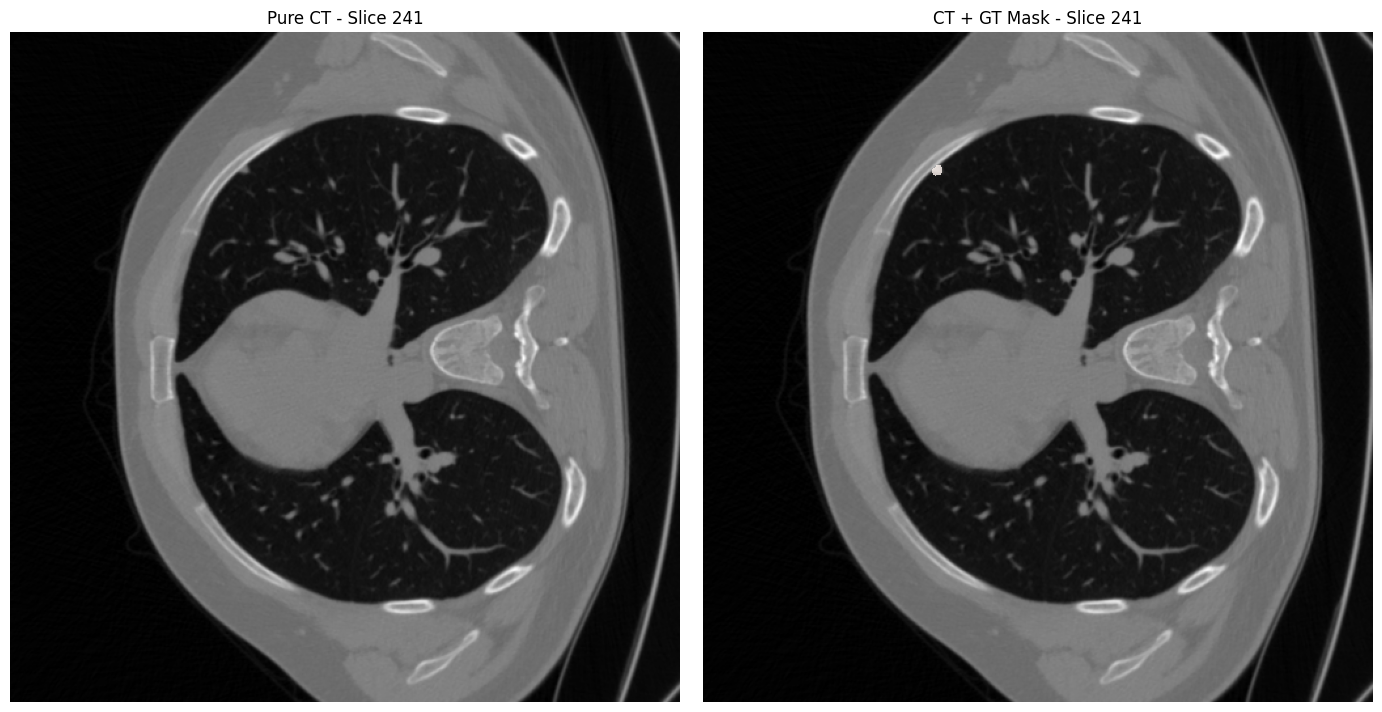

In [24]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Load NIfTI files
# -----------------------------

volume_path = r"/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_7868_a_2.nii.gz"

mask_path = r"/home/chest_ct/code/data/segmentations/segmentations/train_7868_a_2.nii.gz"


ct = nib.load(volume_path).get_fdata()
gt_mask = nib.load(mask_path).get_fdata()


print("CT shape:", ct.shape)
print("GT mask shape:", gt_mask.shape)
print("GT labels:", np.unique(gt_mask)[:20])


# -----------------------------
# Handle mask dimensions
# -----------------------------

if gt_mask.ndim == 4:
    finding = 0
    gt_mask = gt_mask[finding]

print("Using GT mask shape:", gt_mask.shape)


# -----------------------------
# Find slice with most nodule
# -----------------------------

slice_idx = np.argmax(
    (gt_mask > 0).sum(axis=(0, 1))
)

print("Displaying slice:", slice_idx)

# -----------------------------
# Voxel counts
# -----------------------------

ct_voxels = ct.size
mask_voxels = gt_mask.size

positive_mask_voxels = np.count_nonzero(gt_mask > 0)
zero_mask_voxels = mask_voxels - positive_mask_voxels

mask_percentage_of_volume = (positive_mask_voxels / ct_voxels) * 100

print("\nVoxel counts")
print("CT total voxels        :", ct_voxels)
print("Mask total voxels      :", mask_voxels)
print("Mask positive voxels   :", positive_mask_voxels)
print("Mask background voxels :", zero_mask_voxels)
print(f"Mask percentage of CT  : {mask_percentage_of_volume:.6f}%")


# -----------------------------
# Plot volume + overlay
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 7))


# Pure CT volume
axes[0].imshow(
    ct[:, :, slice_idx],
    cmap="gray"
)

axes[0].set_title(f"Pure CT - Slice {slice_idx}")
axes[0].axis("off")


# CT + GT mask overlay
axes[1].imshow(
    ct[:, :, slice_idx],
    cmap="gray"
)

seg = gt_mask[:, :, slice_idx]

axes[1].imshow(
    np.ma.masked_where(
        seg <= 0,
        seg
    ),
    cmap="Reds",
    alpha=0.8,
    interpolation="none"
)

axes[1].set_title(f"CT + GT Mask - Slice {slice_idx}")
axes[1].axis("off")


plt.tight_layout()
plt.show()

Using GT mask shape: (512, 512, 464)
Displaying slice: 241
GT pixels on slice: 48


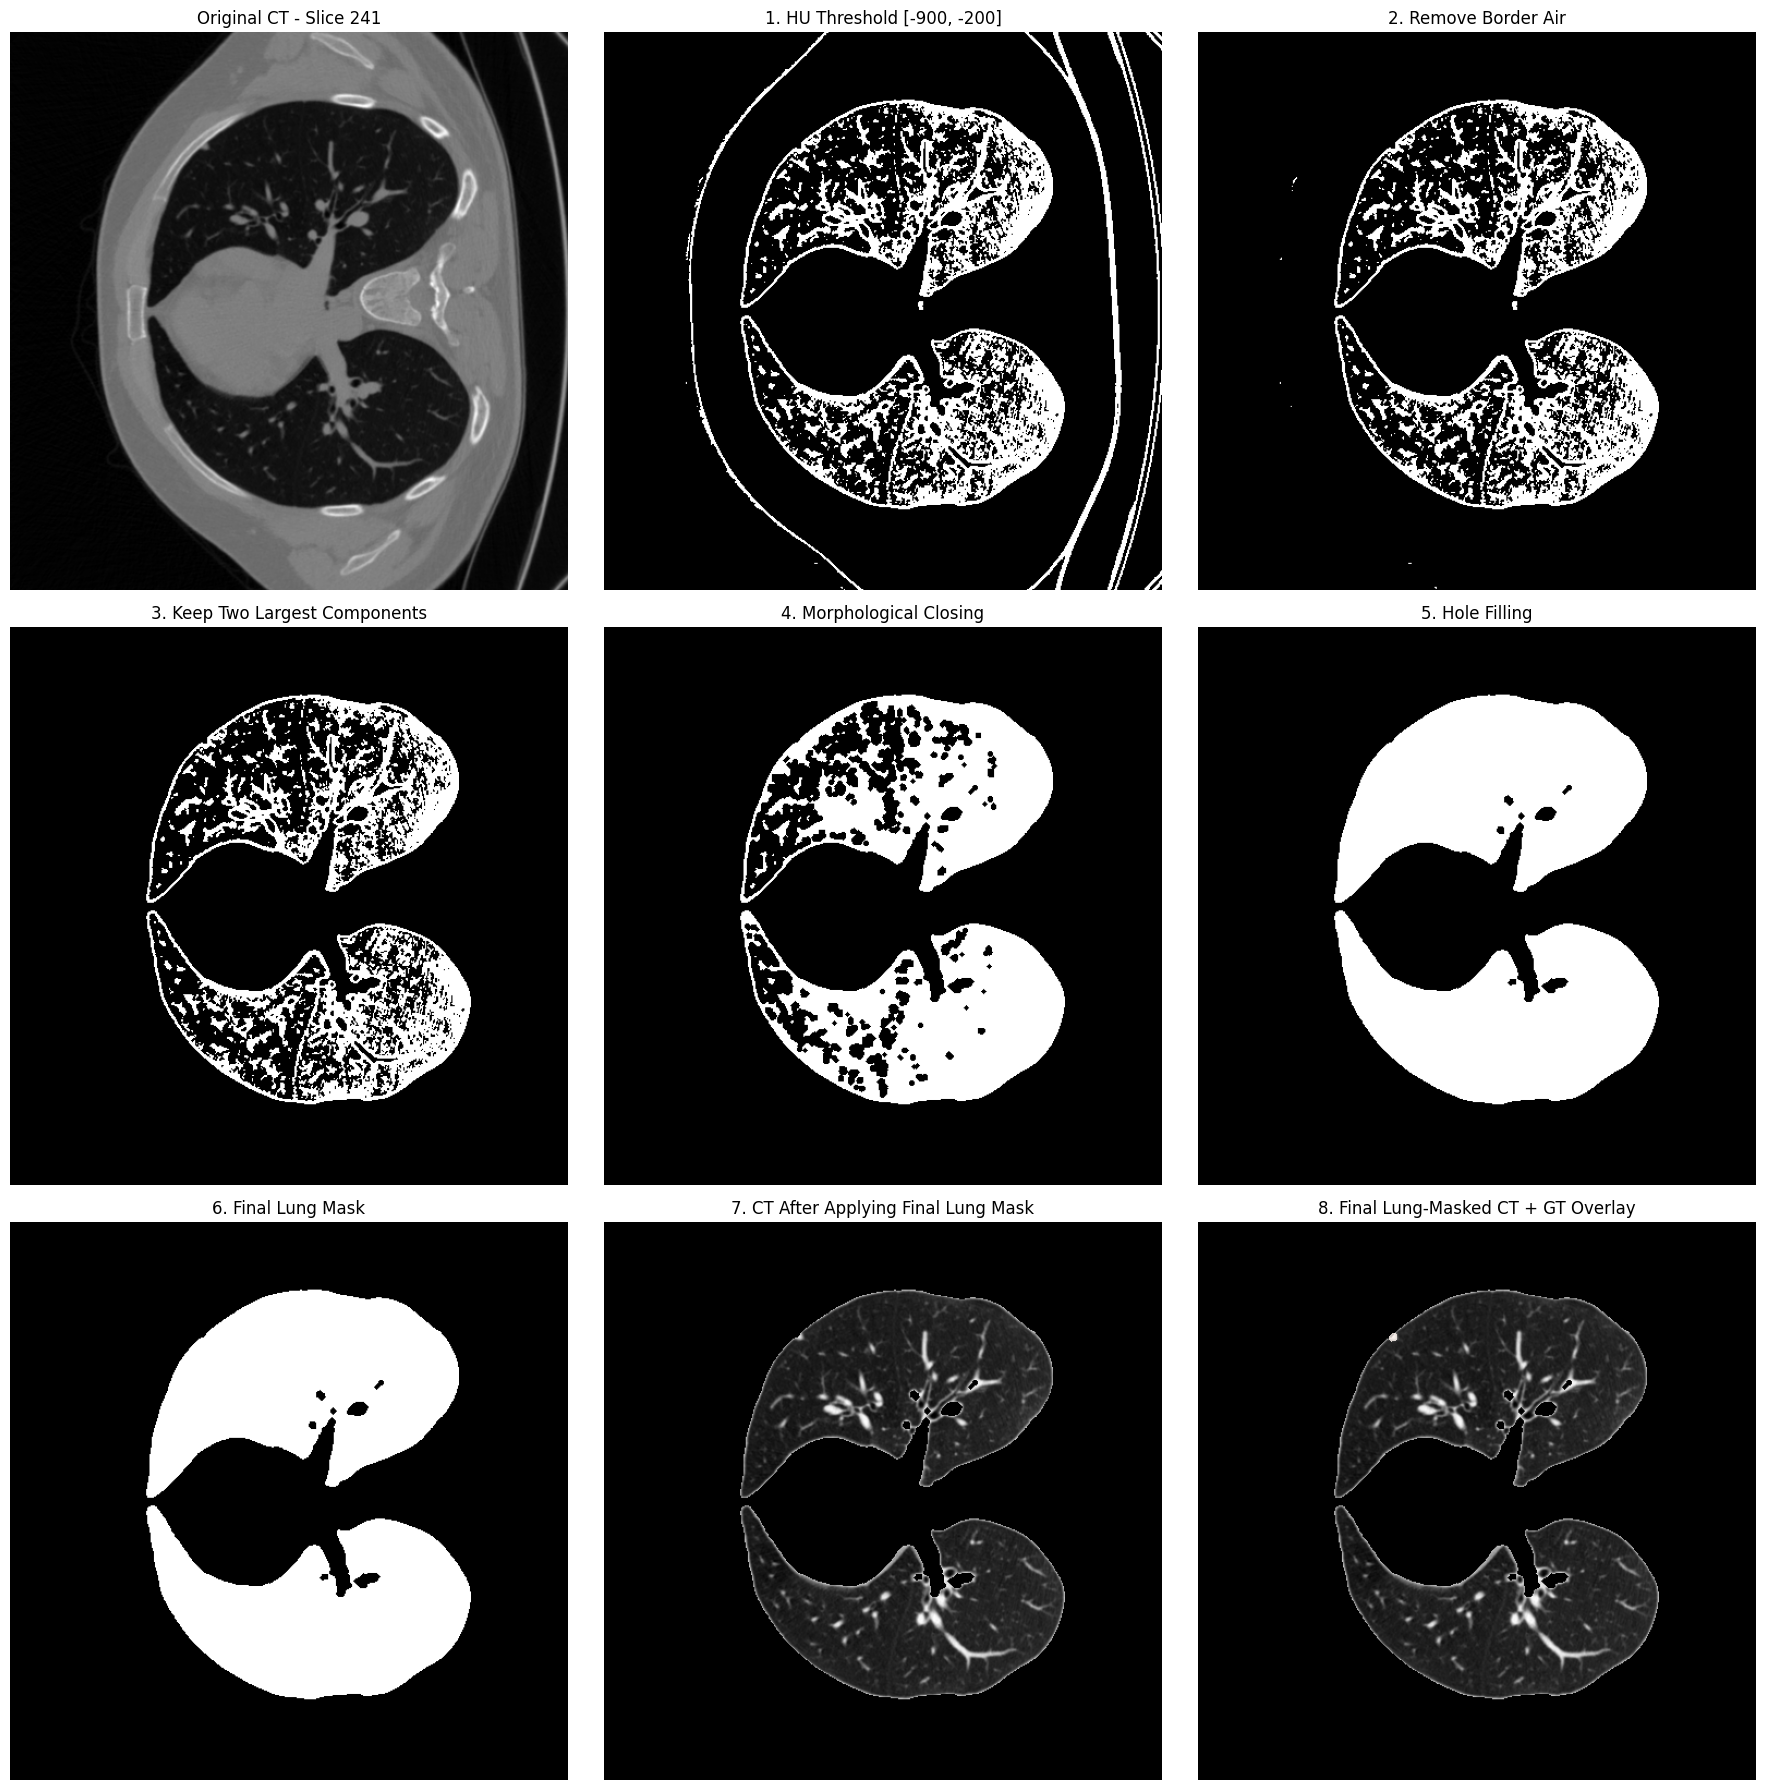

Voxel counts:
HU threshold mask: 11850051
After clear_border: 7889209
After largest components: 7701318
After closing: 11318978
After hole filling: 14537195
Final lung mask: 14537195
GT mask: 215


In [25]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage
from skimage.segmentation import clear_border
from skimage.measure import label


# -----------------------------
# Helper: keep largest components
# -----------------------------
def keep_largest_components(binary_mask, n=2):
    """
    Keep the n largest connected components from a 3D binary mask.
    """
    labeled, num = label(binary_mask, return_num=True, connectivity=1)

    if num == 0:
        return np.zeros_like(binary_mask, dtype=bool)

    component_sizes = np.bincount(labeled.ravel())
    component_sizes[0] = 0  # ignore background

    largest_labels = np.argsort(component_sizes)[-n:]

    return np.isin(labeled, largest_labels)

# -----------------------------
# Handle GT mask dimensions
# -----------------------------
if gt_mask.ndim == 4:
    finding = 0
    gt_mask = gt_mask[finding]

print("Using GT mask shape:", gt_mask.shape)


# -----------------------------
# Find slice with most GT mask pixels
# -----------------------------
slice_idx = int(np.argmax((gt_mask > 0).sum(axis=(0, 1))))

print("Displaying slice:", slice_idx)
print("GT pixels on slice:", int((gt_mask[:, :, slice_idx] > 0).sum()))


# ============================================================
# Lung preprocessing pipeline
# ============================================================

# -----------------------------
# 1. HU threshold
# -----------------------------
lung_candidate = (ct >= -850) & (ct <= -200)


# -----------------------------
# 2. Remove border air slice-by-slice
# -----------------------------
mask_clear = np.zeros_like(lung_candidate, dtype=bool)

for k in range(lung_candidate.shape[2]):
    mask_clear[:, :, k] = clear_border(lung_candidate[:, :, k])


# -----------------------------
# 3. Keep two largest 3D components
# -----------------------------
lungs_only = keep_largest_components(mask_clear, n=2)


# -----------------------------
# 4. Morphological closing
# -----------------------------
structure = ndimage.generate_binary_structure(3, 2)

mask_closed = ndimage.binary_closing(
    lungs_only,
    structure=structure,
    iterations=2
)


# -----------------------------
# 5. Hole filling
# -----------------------------
mask_filled = ndimage.binary_fill_holes(mask_closed)


# -----------------------------
# 6. Final cleanup
# -----------------------------
lungs_final = ndimage.binary_closing(
    mask_filled,
    structure=structure,
    iterations=2
)

lungs_final = ndimage.binary_fill_holes(lungs_final)


# -----------------------------
# Apply final lung mask to CT
# -----------------------------
# Outside-lung voxels are set to a very dark HU value.
ct_lung_only = ct.copy()
ct_lung_only[~lungs_final] = -1000


# ============================================================
# Visualization
# ============================================================

ct_slice = ct[:, :, slice_idx]
gt_slice = gt_mask[:, :, slice_idx]
lung_candidate_slice = lung_candidate[:, :, slice_idx]
mask_clear_slice = mask_clear[:, :, slice_idx]
lungs_only_slice = lungs_only[:, :, slice_idx]
mask_closed_slice = mask_closed[:, :, slice_idx]
mask_filled_slice = mask_filled[:, :, slice_idx]
lungs_final_slice = lungs_final[:, :, slice_idx]
ct_lung_only_slice = ct_lung_only[:, :, slice_idx]


fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.ravel()

# 0. Original CT
axes[0].imshow(ct_slice, cmap="gray")
axes[0].set_title(f"Original CT - Slice {slice_idx}")
axes[0].axis("off")

# 1. HU threshold mask
axes[1].imshow(lung_candidate_slice, cmap="gray")
axes[1].set_title("1. HU Threshold [-900, -200]")
axes[1].axis("off")

# 2. Clear border
axes[2].imshow(mask_clear_slice, cmap="gray")
axes[2].set_title("2. Remove Border Air")
axes[2].axis("off")

# 3. Keep largest components
axes[3].imshow(lungs_only_slice, cmap="gray")
axes[3].set_title("3. Keep Two Largest Components")
axes[3].axis("off")

# 4. Closing
axes[4].imshow(mask_closed_slice, cmap="gray")
axes[4].set_title("4. Morphological Closing")
axes[4].axis("off")

# 5. Hole filling
axes[5].imshow(mask_filled_slice, cmap="gray")
axes[5].set_title("5. Hole Filling")
axes[5].axis("off")

# 6. Final lung mask
axes[6].imshow(lungs_final_slice, cmap="gray")
axes[6].set_title("6. Final Lung Mask")
axes[6].axis("off")

# 7. CT after applying lung mask
axes[7].imshow(ct_lung_only_slice, cmap="gray")
axes[7].set_title("7. CT After Applying Final Lung Mask")
axes[7].axis("off")

# 8. Final CT + GT overlay
axes[8].imshow(ct_lung_only_slice, cmap="gray")

axes[8].imshow(
    np.ma.masked_where(gt_slice <= 0, gt_slice),
    cmap="Reds",
    alpha=0.8,
    interpolation="none"
)

axes[8].set_title("8. Final Lung-Masked CT + GT Overlay")
axes[8].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# Optional: print voxel counts
# ============================================================
print("Voxel counts:")
print("HU threshold mask:", int(lung_candidate.sum()))
print("After clear_border:", int(mask_clear.sum()))
print("After largest components:", int(lungs_only.sum()))
print("After closing:", int(mask_closed.sum()))
print("After hole filling:", int(mask_filled.sum()))
print("Final lung mask:", int(lungs_final.sum()))
print("GT mask:", int((gt_mask > 0).sum()))

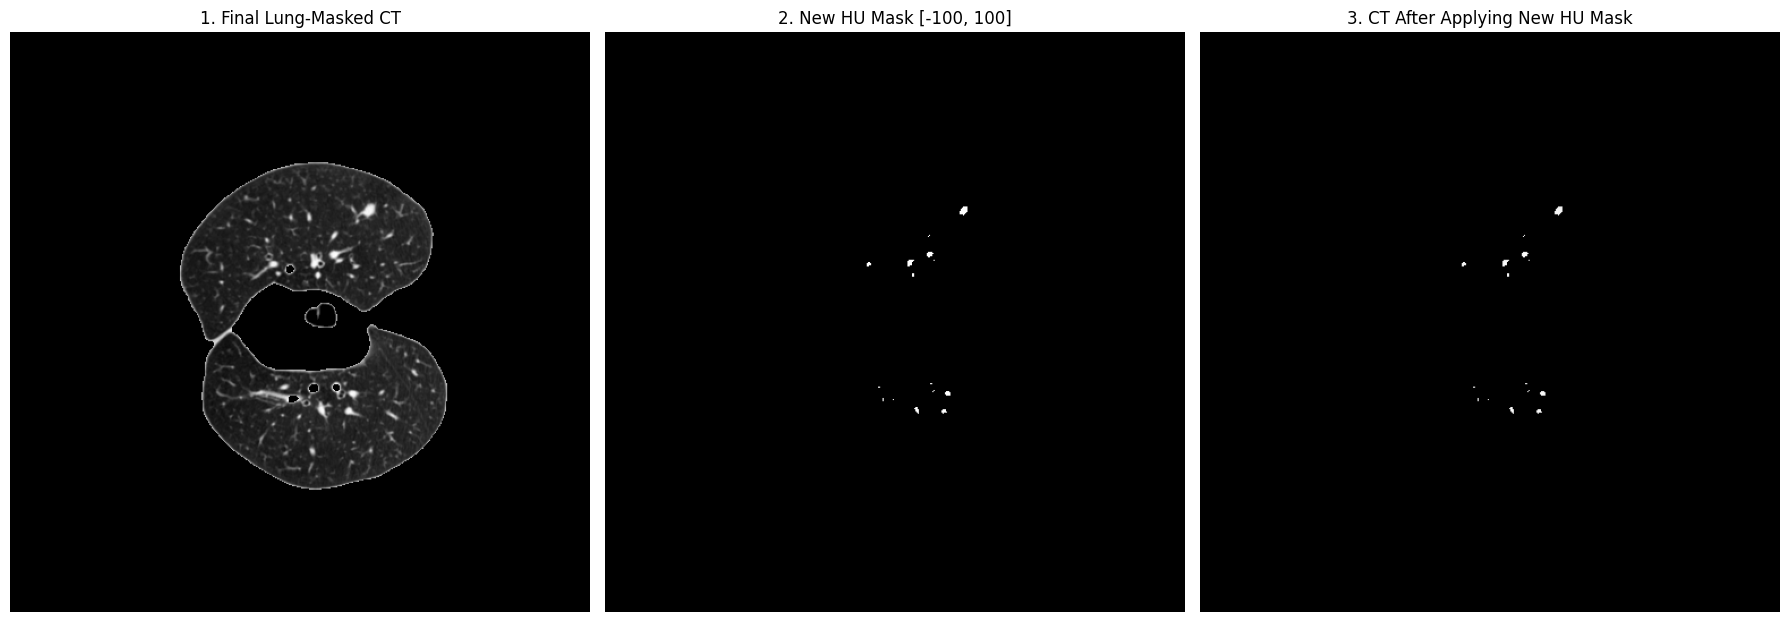

Voxel counts on selected slice:
New HU mask [-100, 100]: 161
GT mask on slice: 269


In [3]:
from skimage.filters import sato
from scipy import ndimage
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# HU mask inside final lung-masked CT
# Target: possible soft-tissue / vessel-like range [-200, 150]
# ============================================================

hu_min, hu_max = -50, 100

new_hu_mask = (
    (ct_lung_only >= hu_min) &
    (ct_lung_only <= hu_max) &
    lungs_final
)

ct_after_new_hu_mask = ct_lung_only.copy()
ct_after_new_hu_mask[~new_hu_mask] = -1000


# ============================================================
# Visualization
# ============================================================

ct_final_slice = ct_lung_only[:, :, slice_idx]
new_hu_mask_slice = new_hu_mask[:, :, slice_idx]
ct_after_mask_slice = ct_after_new_hu_mask[:, :, slice_idx]
gt_slice = gt_mask[:, :, slice_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 12))
axes = axes.ravel()

axes[0].imshow(ct_final_slice, cmap="gray")
axes[0].set_title("1. Final Lung-Masked CT")
axes[0].axis("off")

axes[1].imshow(new_hu_mask_slice, cmap="gray")
axes[1].set_title("2. New HU Mask [-100, 100]")
axes[1].axis("off")

axes[2].imshow(ct_after_mask_slice, cmap="gray")
axes[2].set_title("3. CT After Applying New HU Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# Print voxel counts
# ============================================================

print("Voxel counts on selected slice:")
print("New HU mask [-100, 100]:", int(new_hu_mask[:, :, slice_idx].sum()))
print("GT mask on slice:", int((gt_mask[:, :, slice_idx] > 0).sum()))

In [4]:
from skimage.measure import label, regionprops_table
import pandas as pd
import numpy as np

# 3D connected components
labeled_candidates = label(new_hu_mask, connectivity=1)

# Extract basic 3D features
features = regionprops_table(
    labeled_candidates,
    intensity_image=ct_lung_only,
    properties=[
        "label",
        "area",
        "bbox",
        "centroid",
        "mean_intensity",
        "min_intensity",
        "max_intensity",
        "equivalent_diameter_area",
        "extent",
        "solidity",
    ]
)

features_df = pd.DataFrame(features)

# Add bounding-box sizes
features_df["size_x"] = features_df["bbox-3"] - features_df["bbox-0"]
features_df["size_y"] = features_df["bbox-4"] - features_df["bbox-1"]
features_df["size_z"] = features_df["bbox-5"] - features_df["bbox-2"]

# Add elongation-like feature
features_df["max_size"] = features_df[["size_x", "size_y", "size_z"]].max(axis=1)
features_df["min_size"] = features_df[["size_x", "size_y", "size_z"]].min(axis=1)
features_df["elongation"] = features_df["max_size"] / (features_df["min_size"] + 1e-6)

# Sort by size
features_df = features_df.sort_values("area", ascending=False)

features_df.head(20)

/home/chest_ct/code/.venv/lib/python3.12/site-packages/skimage/measure/_regionprops.py:490: UserWarning: Failed to get convex hull image. Returning empty image, see error message below:
QH6214 qhull input error: not enough points(1) to construct initial simplex (need 4)

While executing:  | qhull i Qt
Options selected for Qhull 2020.2.r 2020/08/31:
  run-id 1608960694  incidence  Qtriangulate  _pre-merge  _zero-centrum
  _maxoutside  0

  return convex_hull_image(self.image)
/home/chest_ct/code/.venv/lib/python3.12/site-packages/skimage/measure/_regionprops.py:704: RuntimeWarning: divide by zero encountered in scalar divide
  return self.area / self.area_convex
/home/chest_ct/code/.venv/lib/python3.12/site-packages/skimage/measure/_regionprops.py:490: UserWarning: Failed to get convex hull image. Returning empty image, see error message below:
QH6214 qhull input error: not enough points(3) to construct initial simplex (need 4)

While executing:  | qhull i Qt
Options selected for Qhull 

,label,area,bbox-0,bbox-1,bbox-2,bbox-3,bbox-4,bbox-5,centroid-0,centroid-1,...,max_intensity,equivalent_diameter_area,extent,solidity,size_x,size_y,size_z,max_size,min_size,elongation
118,119,4261.0,167,269,244,245,343,325,214.242197,292.406712,...,100.0,20.114271,0.009114,0.041221,78,74,81,81,74,1.094595
14,15,3408.0,127,287,146,196,329,224,167.314847,301.646714,...,82.0,18.670975,0.015077,0.181036,69,42,78,78,42,1.857143
1110,1111,2110.0,325,276,195,393,299,244,361.934123,287.577725,...,78.0,15.913338,0.027533,0.174049,68,23,49,68,23,2.956522
859,860,1668.0,304,321,170,338,363,236,316.668465,336.100719,...,66.0,14.714058,0.017698,0.084537,34,42,66,66,34,1.941176
17,18,1453.0,135,238,182,189,275,226,163.473503,256.884377,...,65.0,14.052567,0.016528,0.189390,54,37,44,54,37,1.459459
166,167,1202.0,177,254,306,208,311,366,196.213810,280.049085,...,83.0,13.191736,0.011337,0.105866,31,57,60,60,31,1.935484
725,726,1182.0,239,264,340,257,290,412,246.230118,278.021151,...,51.0,13.118161,0.035078,0.199527,18,26,72,72,18,4.000000
137,138,1127.0,172,312,158,196,354,201,187.485359,328.248447,...,61.0,12.911452,0.026001,0.190404,24,42,43,43,24,1.791667
807,808,941.0,297,319,252,323,350,293,307.803401,333.763018,...,63.0,12.158043,0.028475,0.084078,26,31,41,41,26,1.576923
73,74,929.0,156,212,241,199,247,268,180.400431,235.062433,...,58.0,12.106140,0.022862,0.139406,43,35,27,43,27,1.592593


In [8]:
features_df.describe()

/home/chest_ct/code/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/home/chest_ct/code/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,label,area,bbox-0,bbox-1,bbox-2,bbox-3,bbox-4,bbox-5,centroid-0,centroid-1,...,max_intensity,equivalent_diameter_area,extent,solidity,size_x,size_y,size_z,max_size,min_size,elongation
count,1567.00000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,...,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000,1567.000000
mean,784.00000,32.170389,267.975112,280.767709,251.309509,270.797703,283.625399,254.348437,268.883407,281.668406,...,-18.898532,2.048206,0.824697,inf,2.822591,2.857690,3.038928,3.870453,2.058073,1.565973
std,452.49825,188.594803,76.883443,48.459944,76.828760,76.751847,48.362226,76.921008,76.657256,48.228852,...,31.259010,1.940213,0.303271,NaN,6.637517,6.320781,7.358830,8.874055,4.149329,0.916369
min,1.00000,1.000000,102.000000,148.000000,66.000000,103.000000,149.000000,67.000000,102.000000,148.000000,...,-50.000000,1.240701,0.007028,0.041221,1.000000,1.000000,1.000000,1.000000,1.000000,0.999999
25%,392.50000,1.000000,199.000000,253.000000,206.000000,201.000000,255.000000,209.000000,199.900000,253.000000,...,-42.000000,1.240701,0.750000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,0.999999
50%,784.00000,1.000000,285.000000,286.000000,252.000000,287.000000,289.000000,255.000000,285.333333,287.000000,...,-29.000000,1.240701,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,0.999999
75%,1175.50000,4.000000,331.000000,315.000000,308.500000,334.000000,317.000000,312.000000,332.000000,315.628788,...,-8.000000,1.969490,1.000000,NaN,2.000000,2.000000,2.000000,3.000000,1.000000,1.999998
max,1567.00000,4261.000000,431.000000,398.000000,450.000000,434.000000,399.000000,451.000000,432.166667,398.000000,...,100.000000,20.114271,1.000000,inf,78.000000,74.000000,81.000000,81.000000,74.000000,8.249998


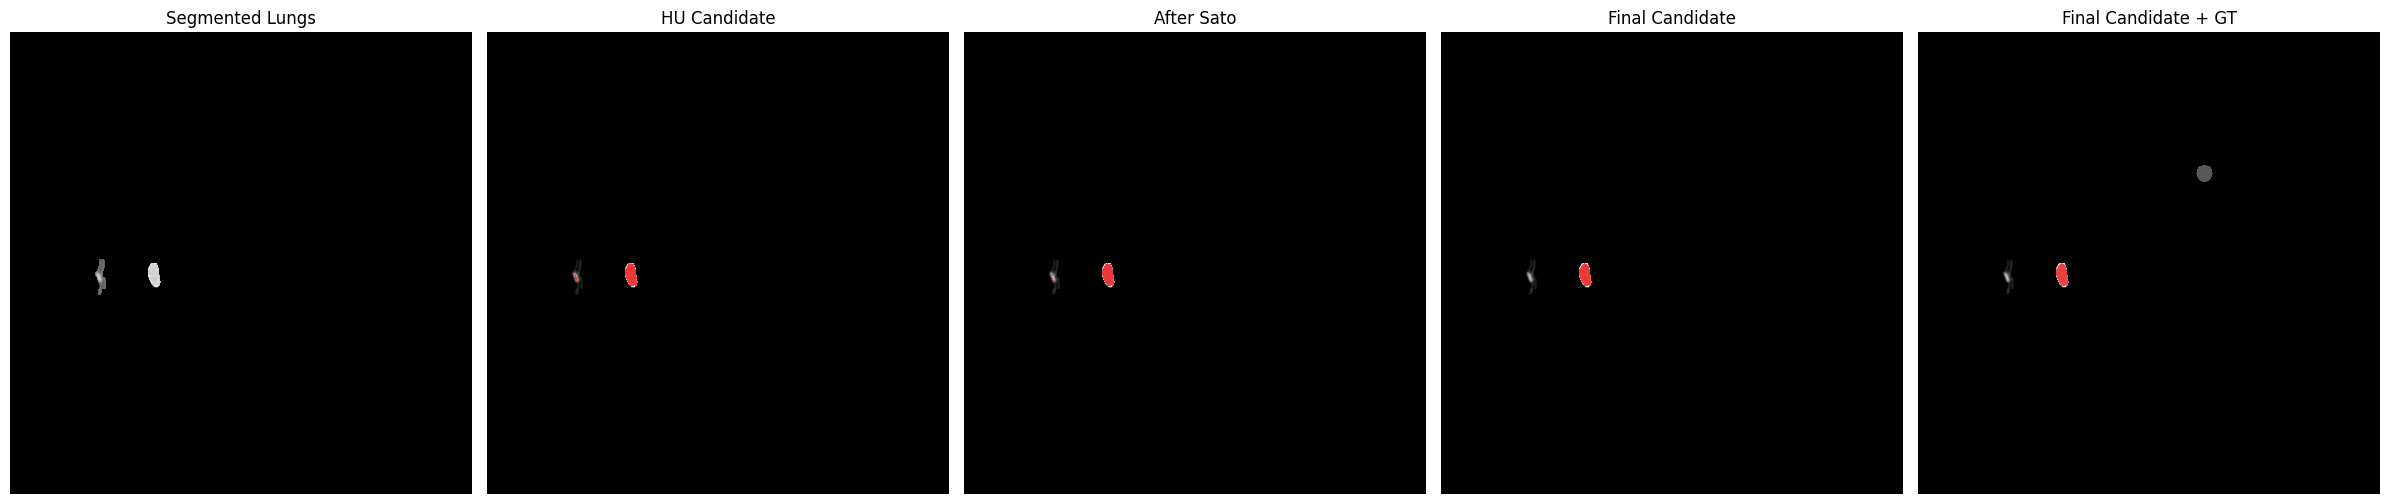

Voxel counts
Lung mask        : 91323
HU candidate     : 29078
After Sato       : 28331
After closing    : 28883
After fill holes : 28883
After morphology : 28459
Final kept       : 28406
GT               : 7253

Whole-volume metrics
TP          : 0
FP          : 28406
FN          : 7253
TN          : 120812725
Dice / F1   : 0.0000
IoU         : 0.0000
Precision   : 0.0000
Recall      : 0.0000
Specificity : 0.9998


In [16]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage
from skimage.filters import sato
from skimage.measure import label, regionprops
from skimage.segmentation import clear_border


# ============================================================
# Helper: keep largest 3D connected components
# ============================================================
def keep_largest_components(binary_mask, n=2):
    labeled, num = label(binary_mask, return_num=True, connectivity=1)

    if num == 0:
        return np.zeros_like(binary_mask, dtype=bool)

    component_sizes = np.bincount(labeled.ravel())
    component_sizes[0] = 0
    largest_labels = np.argsort(component_sizes)[-n:]

    return np.isin(labeled, largest_labels)


# ============================================================
# Whole pipeline:
# 1. Lung segmentation
# 2. HU nodule candidate
# 3. Sato vessel removal
# 4. Morphology + component filtering
# 5. Whole-volume metrics
# ============================================================

# ------------------------------------------------------------
# GT handling
# ------------------------------------------------------------
if gt_mask.ndim == 4:
    gt = gt_mask[0] > 0
else:
    gt = gt_mask > 0

slice_idx = int(np.argmax(gt.sum(axis=(0, 1))))

# ------------------------------------------------------------
# 1. Lung segmentation
# ------------------------------------------------------------
lung_candidate = (ct >= -900) & (ct <= 200)

mask_clear = np.zeros_like(lung_candidate, dtype=bool)
for k in range(ct.shape[2]):
    mask_clear[:, :, k] = clear_border(lung_candidate[:, :, k])

lungs_only = keep_largest_components(mask_clear, n=2)

structure_3d = ndimage.generate_binary_structure(3, 2)

mask_closed = ndimage.binary_closing(lungs_only, structure=structure_3d, iterations=2)
mask_filled = ndimage.binary_fill_holes(mask_closed)
lungs_final = ndimage.binary_closing(mask_filled, structure=structure_3d, iterations=2)
lungs_final = ndimage.binary_fill_holes(lungs_final)

ct_lung_only = ct.copy()
ct_lung_only[~lungs_final] = -1000

# ------------------------------------------------------------
# 2. HU threshold inside segmented lungs
# ------------------------------------------------------------
nodule_candidate_3d = lungs_final & ((ct_lung_only >= -100) & (ct_lung_only <= 150))

# ------------------------------------------------------------
# 3. Sato vessel removal slice-by-slice
# ------------------------------------------------------------
candidate_after_sato_3d = np.zeros_like(nodule_candidate_3d, dtype=bool)
vessel_mask_3d = np.zeros_like(nodule_candidate_3d, dtype=bool)

for k in range(ct_lung_only.shape[2]):
    ct_slice = ct_lung_only[:, :, k]
    lung_slice = lungs_final[:, :, k]
    candidate_slice = nodule_candidate_3d[:, :, k]

    if not np.any(lung_slice):
        continue

    ct_norm_slice = np.clip(ct_slice, -900, 200)
    ct_norm_slice = (ct_norm_slice + 900) / 1100.0
    ct_norm_slice[~lung_slice] = 0

    vesselness_slice = sato(ct_norm_slice, sigmas=(1, 2), black_ridges=False)

    lung_vesselness = vesselness_slice[lung_slice]
    if lung_vesselness.size > 0:
        vessel_thresh = np.percentile(lung_vesselness, 98.5)
        vessel_slice = (vesselness_slice >= vessel_thresh) & lung_slice
    else:
        vessel_slice = np.zeros_like(lung_slice, dtype=bool)

    vessel_mask_3d[:, :, k] = vessel_slice
    candidate_after_sato_3d[:, :, k] = candidate_slice & ~vessel_slice

# ------------------------------------------------------------
# 4. Morphology + size filtering slice-by-slice
# ------------------------------------------------------------
structure_2d = ndimage.generate_binary_structure(2, 1)
min_area = 20

candidate_closed_3d = np.zeros_like(candidate_after_sato_3d, dtype=bool)
candidate_filled_3d = np.zeros_like(candidate_after_sato_3d, dtype=bool)
candidate_clean_3d = np.zeros_like(candidate_after_sato_3d, dtype=bool)
final_candidate_3d = np.zeros_like(candidate_after_sato_3d, dtype=bool)

for k in range(candidate_after_sato_3d.shape[2]):
    candidate_after_sato = candidate_after_sato_3d[:, :, k]

    candidate_closed = ndimage.binary_closing(
        candidate_after_sato,
        structure=structure_2d,
        iterations=2
    )

    candidate_filled = ndimage.binary_fill_holes(candidate_closed)

    candidate_clean = ndimage.binary_opening(
        candidate_filled,
        structure=structure_2d,
        iterations=1
    )

    labels_2d = label(candidate_clean)
    props_2d = regionprops(labels_2d)

    final_candidate_2d = np.zeros_like(candidate_clean, dtype=bool)

    for region in props_2d:
        if region.area >= min_area:
            final_candidate_2d[labels_2d == region.label] = True

    candidate_closed_3d[:, :, k] = candidate_closed
    candidate_filled_3d[:, :, k] = candidate_filled
    candidate_clean_3d[:, :, k] = candidate_clean
    final_candidate_3d[:, :, k] = final_candidate_2d

# ------------------------------------------------------------
# 5. Whole-volume metrics
# ------------------------------------------------------------
pred = final_candidate_3d.astype(bool)

tp = np.logical_and(pred, gt).sum()
fp = np.logical_and(pred, ~gt).sum()
fn = np.logical_and(~pred, gt).sum()
tn = np.logical_and(~pred, ~gt).sum()

dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

# ------------------------------------------------------------
# 6. Visualization on selected slice
# ------------------------------------------------------------
ct_slice = ct_lung_only[:, :, slice_idx]
lung_slice = lungs_final[:, :, slice_idx]
hu_slice = nodule_candidate_3d[:, :, slice_idx]
sato_slice = candidate_after_sato_3d[:, :, slice_idx]
final_slice = final_candidate_3d[:, :, slice_idx]
gt_slice = gt[:, :, slice_idx]

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

axes[0].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[0].imshow(np.ma.masked_where(~lung_slice, lung_slice),
               cmap="Greens", alpha=0.35, interpolation="none")
axes[0].set_title("Segmented Lungs")
axes[0].axis("off")

axes[1].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[1].imshow(np.ma.masked_where(~hu_slice, hu_slice),
               cmap="autumn", alpha=0.7, interpolation="none")
axes[1].set_title("HU Candidate")
axes[1].axis("off")

axes[2].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[2].imshow(np.ma.masked_where(~sato_slice, sato_slice),
               cmap="autumn", alpha=0.7, interpolation="none")
axes[2].set_title("After Sato")
axes[2].axis("off")

axes[3].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[3].imshow(np.ma.masked_where(~final_slice, final_slice),
               cmap="autumn", alpha=0.7, interpolation="none")
axes[3].set_title("Final Candidate")
axes[3].axis("off")

axes[4].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[4].imshow(np.ma.masked_where(~final_slice, final_slice),
               cmap="autumn", alpha=0.65, interpolation="none")
axes[4].imshow(np.ma.masked_where(~gt_slice, gt_slice),
               cmap="Blues", alpha=0.35, interpolation="none")
axes[4].set_title("Final Candidate + GT")
axes[4].axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Counts and metrics
# ------------------------------------------------------------
print("Voxel counts")
print("Lung mask        :", int(lungs_final.sum()))
print("HU candidate     :", int(nodule_candidate_3d.sum()))
print("After Sato       :", int(candidate_after_sato_3d.sum()))
print("After closing    :", int(candidate_closed_3d.sum()))
print("After fill holes :", int(candidate_filled_3d.sum()))
print("After morphology :", int(candidate_clean_3d.sum()))
print("Final kept       :", int(final_candidate_3d.sum()))
print("GT               :", int(gt.sum()))

print("\nWhole-volume metrics")
print(f"TP          : {int(tp)}")
print(f"FP          : {int(fp)}")
print(f"FN          : {int(fn)}")
print(f"TN          : {int(tn)}")
print(f"Dice / F1   : {dice:.4f}")
print(f"IoU         : {iou:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")

Number of GT voxels: 215

HU distribution inside GT mask
Min : -826.0
P1  : -791.58
P5  : -714.9
P25 : -555.5
P50 : -358.0
P75 : -137.0
P95 : 17.799999999999727
P99 : 234.099999999998
Max : 286.0
Mean: -350.4697674418605
Median: -358.0
Std : 246.6930260181516


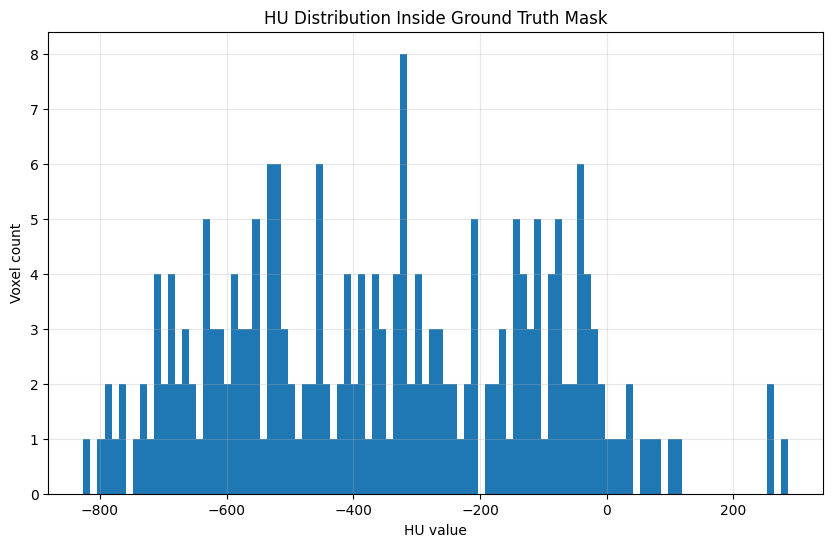

In [26]:
# ============================================================
# HU distribution inside GT mask
# ============================================================

# If GT mask is multi-channel, select one finding/channel
if gt_mask.ndim == 4:
    finding = 0
    gt_mask_single = gt_mask[finding]
else:
    gt_mask_single = gt_mask

# Convert GT to boolean mask
gt_bool = gt_mask_single > 0

# Extract HU values inside GT
gt_hu_values = ct[gt_bool]

# Remove NaN / inf if any
gt_hu_values = gt_hu_values[np.isfinite(gt_hu_values)]

print("Number of GT voxels:", gt_hu_values.size)

if gt_hu_values.size > 0:
    print("\nHU distribution inside GT mask")
    print("Min :", float(np.min(gt_hu_values)))
    print("P1  :", float(np.percentile(gt_hu_values, 1)))
    print("P5  :", float(np.percentile(gt_hu_values, 5)))
    print("P25 :", float(np.percentile(gt_hu_values, 25)))
    print("P50 :", float(np.percentile(gt_hu_values, 50)))  # median
    print("P75 :", float(np.percentile(gt_hu_values, 75)))
    print("P95 :", float(np.percentile(gt_hu_values, 95)))
    print("P99 :", float(np.percentile(gt_hu_values, 99)))
    print("Max :", float(np.max(gt_hu_values)))
    print("Mean:", float(np.mean(gt_hu_values)))
    print("Median:", float(np.median(gt_hu_values)))
    print("Std :", float(np.std(gt_hu_values)))

    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(gt_hu_values, bins=100)
    plt.xlabel("HU value")
    plt.ylabel("Voxel count")
    plt.title("HU Distribution Inside Ground Truth Mask")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("GT mask is empty.")

Selected CTs: 524

Processed: 524
Missing CTs: 0
Missing masks: 0

========== GLOBAL NODULE HU STATS ==========
Voxel count: 2191527
P1 : -982.0
P5 : -859.0
P25: -402.0
P50: 6.0
P75: 40.0
P95: 81.0
P99: 118.0
Min   : -1091.0
Max   : 3071.0
Mean  : -179.4037709779528
Std   : 338.8326628855829


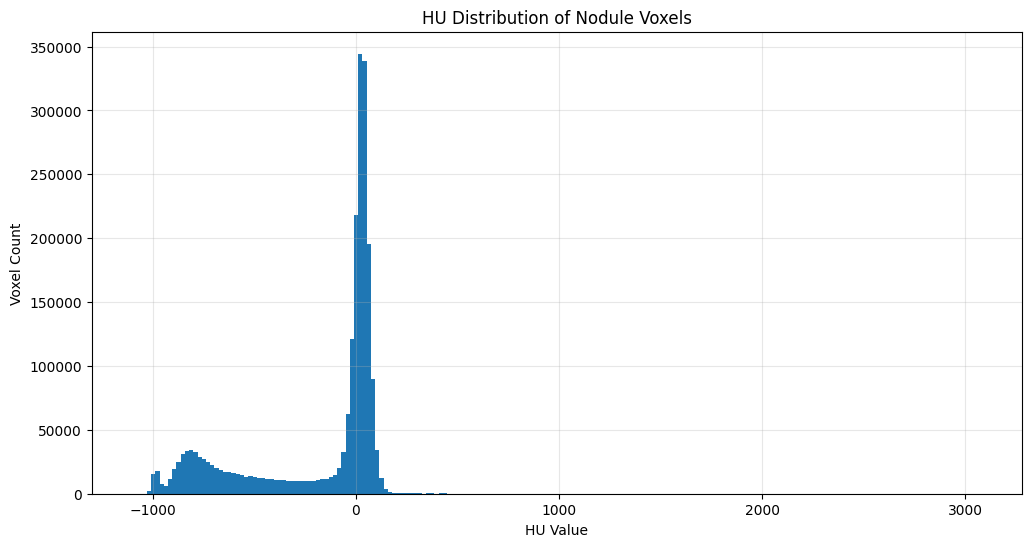

In [2]:
import os
import json
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths
# --------------------------------------------------

volume_dir = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed"
mask_dir = "/home/chest_ct/code/data/segmentations/segmentations"

json_path = "/home/chest_ct/code/data/rexgrounding-ct/dataset_2d.json"

# --------------------------------------------------
# Load selected cases
# --------------------------------------------------

with open(json_path, "r") as f:
    dataset = json.load(f)

selected_files = set(
    dataset.get("train", []) +
    dataset.get("test", [])
)

print(f"Selected CTs: {len(selected_files)}")

# --------------------------------------------------
# Collect HU values
# --------------------------------------------------

all_hu_values = []

processed = 0
missing_ct = []
missing_mask = []

for filename in sorted(selected_files):

    volume_path = os.path.join(volume_dir, filename)
    mask_path = os.path.join(mask_dir, filename)

    if not os.path.exists(volume_path):
        missing_ct.append(filename)
        continue

    if not os.path.exists(mask_path):
        missing_mask.append(filename)
        continue

    try:
        ct = nib.load(volume_path).get_fdata()
        gt_mask = nib.load(mask_path).get_fdata()

        # Multi-channel mask -> union of channels
        if gt_mask.ndim == 4:
            gt_mask = np.any(gt_mask > 0, axis=0)
        else:
            gt_mask = gt_mask > 0

        hu_values = ct[gt_mask]
        hu_values = hu_values[np.isfinite(hu_values)]

        if hu_values.size > 0:
            all_hu_values.append(hu_values)

        processed += 1

    except Exception as e:
        print(f"Error processing {filename}: {e}")

# --------------------------------------------------
# Summary
# --------------------------------------------------

print(f"\nProcessed: {processed}")
print(f"Missing CTs: {len(missing_ct)}")
print(f"Missing masks: {len(missing_mask)}")

if missing_ct:
    print("\nMissing CT files:")
    for x in missing_ct[:20]:
        print(" ", x)

if missing_mask:
    print("\nMissing mask files:")
    for x in missing_mask[:20]:
        print(" ", x)

# --------------------------------------------------
# HU statistics
# --------------------------------------------------

all_hu_values = np.concatenate(all_hu_values)

print("\n========== GLOBAL NODULE HU STATS ==========")
print("Voxel count:", all_hu_values.size)

for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"P{p:<2}:", float(np.percentile(all_hu_values, p)))

print("Min   :", float(np.min(all_hu_values)))
print("Max   :", float(np.max(all_hu_values)))
print("Mean  :", float(np.mean(all_hu_values)))
print("Std   :", float(np.std(all_hu_values)))

# --------------------------------------------------
# Histogram
# --------------------------------------------------

plt.figure(figsize=(12, 6))
plt.hist(all_hu_values, bins=200)
plt.xlabel("HU Value")
plt.ylabel("Voxel Count")
plt.title("HU Distribution of Nodule Voxels")
plt.grid(alpha=0.3)
plt.show()

In [3]:
import pandas as pd
from scipy import ndimage as ndi
from skimage import measure

nodule_records = []

for filename in sorted(selected_files):
    volume_path = os.path.join(volume_dir, filename)
    mask_path = os.path.join(mask_dir, filename)
    if not os.path.exists(volume_path) or not os.path.exists(mask_path):
        continue

    try:
        ct_img = nib.load(volume_path)
        ct = ct_img.get_fdata()
        spacing = ct_img.header.get_zooms()[:3]  # (x, y, z) mm
        voxel_vol_mm3 = float(np.prod(spacing))

        gt_img = nib.load(mask_path)
        gt_mask = gt_img.get_fdata()
        if gt_mask.ndim == 4:
            gt_mask = np.any(gt_mask > 0, axis=0)
        else:
            gt_mask = gt_mask > 0

        # Connected components -> individual nodule instances
        labeled, n_components = ndi.label(gt_mask, structure=np.ones((3, 3, 3)))

        for comp_id in range(1, n_components + 1):
            comp_mask = labeled == comp_id
            voxel_count = int(comp_mask.sum())
            if voxel_count < 2:  # drop single-voxel noise
                continue

            hu_in = ct[comp_mask]
            hu_in = hu_in[np.isfinite(hu_in)]
            if hu_in.size == 0:
                continue

            # --- Shell around the nodule for local contrast ---
            dilated = ndi.binary_dilation(comp_mask, iterations=2)
            shell = dilated & ~comp_mask
            hu_shell = ct[shell]
            hu_shell = hu_shell[np.isfinite(hu_shell)]

            # --- Shape descriptors via regionprops (spacing-aware) ---
            props = measure.regionprops(comp_mask.astype(np.uint8), spacing=spacing)[0]
            bbox = props.bbox  # (minr, minc, minz, maxr, maxc, maxz)
            bbox_dims_mm = [
                (bbox[3] - bbox[0]) * spacing[0],
                (bbox[4] - bbox[1]) * spacing[1],
                (bbox[5] - bbox[2]) * spacing[2],
            ]
            volume_mm3 = voxel_count * voxel_vol_mm3
            equiv_diam_mm = 2 * (3 * volume_mm3 / (4 * np.pi)) ** (1 / 3)

            # Sphericity: ratio of equiv-sphere surface area to actual surface area
            try:
                verts, faces, _, _ = measure.marching_cubes(
                    comp_mask.astype(np.uint8), level=0.5, spacing=spacing
                )
                surface_area_mm2 = measure.mesh_surface_area(verts, faces)
                sphere_sa = np.pi ** (1 / 3) * (6 * volume_mm3) ** (2 / 3)
                sphericity = sphere_sa / surface_area_mm2 if surface_area_mm2 > 0 else np.nan
            except Exception:
                surface_area_mm2 = np.nan
                sphericity = np.nan

            extent = props.extent if hasattr(props, "extent") else voxel_count / np.prod(
                [bbox[3]-bbox[0], bbox[4]-bbox[1], bbox[5]-bbox[2]]
            )

            nodule_records.append({
                "case": filename,
                "component_id": comp_id,
                "voxel_count": voxel_count,
                "volume_mm3": volume_mm3,
                "equiv_diameter_mm": equiv_diam_mm,
                "bbox_dim_x_mm": bbox_dims_mm[0],
                "bbox_dim_y_mm": bbox_dims_mm[1],
                "bbox_dim_z_mm": bbox_dims_mm[2],
                "elongation": max(bbox_dims_mm) / (min(bbox_dims_mm) + 1e-6),
                "extent": extent,
                "sphericity": sphericity,
                "surface_area_mm2": surface_area_mm2,
                "hu_mean": float(hu_in.mean()),
                "hu_std": float(hu_in.std()),
                "hu_min": float(hu_in.min()),
                "hu_max": float(hu_in.max()),
                "hu_p10": float(np.percentile(hu_in, 10)),
                "hu_p90": float(np.percentile(hu_in, 90)),
                "shell_hu_mean": float(hu_shell.mean()) if hu_shell.size else np.nan,
                "hu_contrast": float(hu_in.mean() - hu_shell.mean()) if hu_shell.size else np.nan,
                "centroid_z_frac": props.centroid[2] / ct.shape[2],  # slice position, 0=bottom
            })

    except Exception as e:
        print(f"Error processing {filename}: {e}")

nodules_df = pd.DataFrame(nodule_records)
print(f"Total nodule instances: {len(nodules_df)}")
nodules_df.head()

Total nodule instances: 1225


,case,component_id,voxel_count,volume_mm3,equiv_diameter_mm,bbox_dim_x_mm,bbox_dim_y_mm,bbox_dim_z_mm,elongation,extent,...,surface_area_mm2,hu_mean,hu_std,hu_min,hu_max,hu_p10,hu_p90,shell_hu_mean,hu_contrast,centroid_z_frac
0,train_10000_a_1.nii.gz,1,207,77.360470,5.286564,6.113281,6.113281,5.00,1.222656,0.414000,...,108.087906,-525.270531,208.738734,-865.0,41.0,-771.8,-199.4,-826.900648,301.630117,0.562352
1,train_10000_a_1.nii.gz,2,109,40.735706,4.268994,4.890625,6.724609,4.00,1.681152,0.309659,...,76.831581,-319.165138,323.716166,-832.0,767.0,-728.6,89.6,-408.448454,89.283316,0.867763
2,train_10017_a_2.nii.gz,1,126,54.549540,4.705410,6.078125,4.558594,3.75,1.620833,0.525000,...,83.102524,-482.587302,159.686562,-773.0,-84.0,-671.5,-245.5,-731.212465,248.625163,0.329828
3,train_10083_a_2.nii.gz,1,169,58.219302,4.808646,6.099609,5.421875,4.50,1.355469,0.391204,...,93.462318,-356.461538,229.730663,-783.0,153.0,-663.2,-35.8,-551.191038,194.729499,0.537659
4,train_10083_a_2.nii.gz,2,331,114.027154,6.016398,6.777344,7.455078,5.25,1.420015,0.429870,...,141.457855,-516.006042,200.181941,-849.0,-53.0,-753.0,-217.0,-853.061056,337.055014,0.415801


In [17]:
print(nodules_df[["equiv_diameter_mm", "sphericity", "elongation", "surface_area_mm2", "centroid_z_frac",
                   "extent", "hu_mean", "voxel_count", "volume_mm3", "shell_hu_mean"]].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))

       equiv_diameter_mm   sphericity   elongation  surface_area_mm2  \
count        1225.000000  1225.000000  1225.000000       1225.000000   
mean            6.163156     0.789138     2.282999        299.866486   
std             4.401835     0.114961     2.186166       1937.860596   
min             1.269103     0.121409     1.000390          3.079607   
1%              1.980112     0.444349     1.067079         12.471988   
5%              3.043786     0.601675     1.189845         33.816942   
25%             4.298597     0.728071     1.482060         69.001770   
50%             5.372599     0.803042     1.845703        113.062881   
75%             6.849097     0.865054     2.430555        198.380768   
95%            11.171959     0.931560     4.004579        582.518225   
99%            19.750870     1.007955    10.077470       1965.376377   
max            85.823649     1.643042    34.133278      57846.570312   

       centroid_z_frac       extent      hu_mean   voxel_count 

In [13]:
print(nodules_df[["sphericity"]].describe(percentiles=[.01,.05,.25,.5,.75,.85,.95,.99]))

        sphericity
count  1225.000000
mean      0.789138
std       0.114961
min       0.121409
1%        0.444349
5%        0.601675
25%       0.728071
50%       0.803042
75%       0.865054
85%       0.891677
95%       0.931560
99%       1.007955
max       1.643042


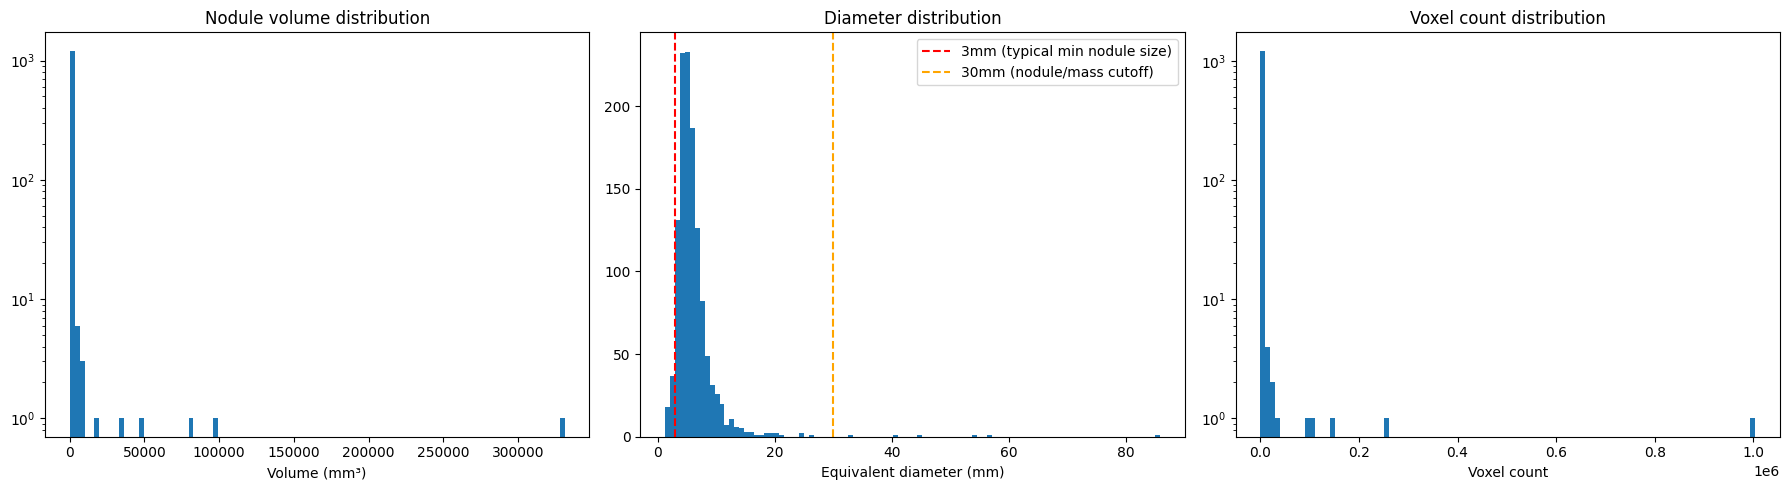

count    1225.000000
mean        6.163156
std         4.401835
min         1.269103
25%         4.298597
50%         5.372599
75%         6.849097
max        85.823649
Name: equiv_diameter_mm, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(nodules_df["volume_mm3"], bins=100)
axes[0].set_xlabel("Volume (mm³)")
axes[0].set_title("Nodule volume distribution")
axes[0].set_yscale("log")

axes[1].hist(nodules_df["equiv_diameter_mm"], bins=100)
axes[1].axvline(3, color="r", ls="--", label="3mm (typical min nodule size)")
axes[1].axvline(30, color="orange", ls="--", label="30mm (nodule/mass cutoff)")
axes[1].set_xlabel("Equivalent diameter (mm)")
axes[1].set_title("Diameter distribution")
axes[1].legend()

axes[2].hist(nodules_df["voxel_count"], bins=100)
axes[2].set_xlabel("Voxel count")
axes[2].set_title("Voxel count distribution")
axes[2].set_yscale("log")

plt.tight_layout()
plt.show()

print(nodules_df["equiv_diameter_mm"].describe())

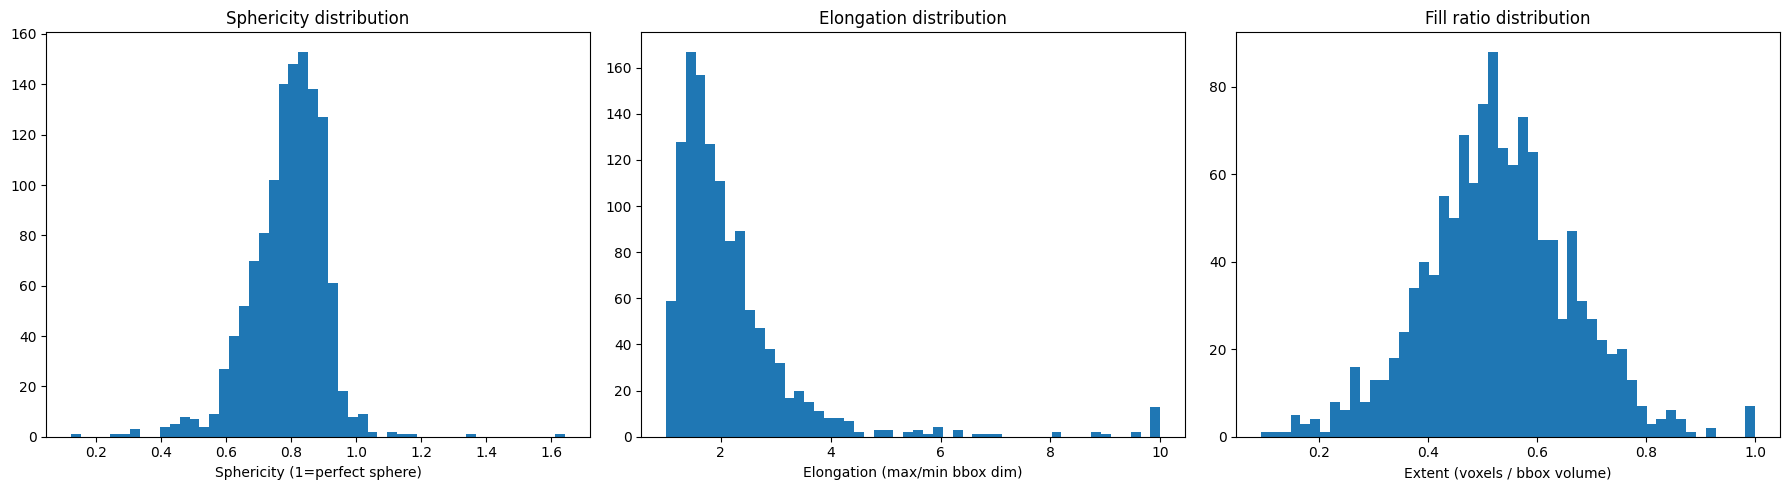

        sphericity   elongation       extent
count  1225.000000  1225.000000  1225.000000
mean      0.789138     2.282999     0.528913
std       0.114961     2.186166     0.135456
min       0.121409     1.000390     0.093444
25%       0.728071     1.482060     0.445455
50%       0.803042     1.845703     0.524837
75%       0.865054     2.430555     0.611111
max       1.643042    34.133278     1.000000


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(nodules_df["sphericity"].dropna(), bins=50)
axes[0].set_xlabel("Sphericity (1=perfect sphere)")
axes[0].set_title("Sphericity distribution")

axes[1].hist(nodules_df["elongation"].clip(upper=10), bins=50)
axes[1].set_xlabel("Elongation (max/min bbox dim)")
axes[1].set_title("Elongation distribution")

axes[2].hist(nodules_df["extent"].dropna(), bins=50)
axes[2].set_xlabel("Extent (voxels / bbox volume)")
axes[2].set_title("Fill ratio distribution")

plt.tight_layout()
plt.show()

print(nodules_df[["sphericity", "elongation", "extent"]].describe())

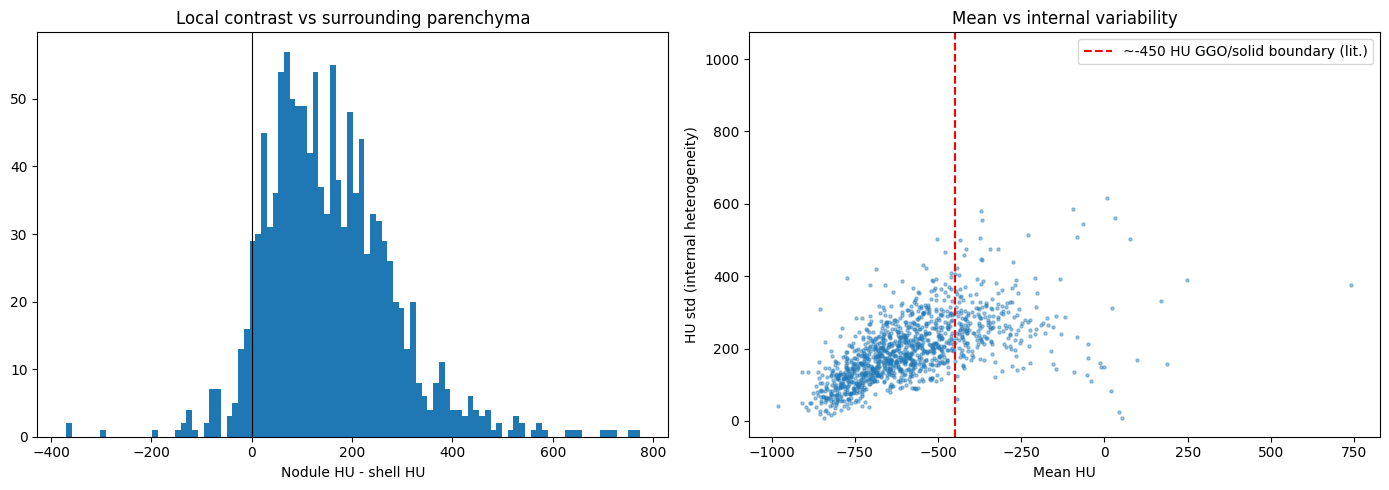

GGO-like (<-450 HU): 974 (79.5%)
Solid-like (>=-450 HU): 251 (20.5%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(nodules_df["hu_contrast"].dropna(), bins=100)
axes[0].axvline(0, color="k", lw=0.8)
axes[0].set_xlabel("Nodule HU - shell HU")
axes[0].set_title("Local contrast vs surrounding parenchyma")

axes[1].scatter(nodules_df["hu_mean"], nodules_df["hu_std"], s=5, alpha=0.4)
axes[1].axvline(-450, color="r", ls="--", label="~-450 HU GGO/solid boundary (lit.)")
axes[1].set_xlabel("Mean HU")
axes[1].set_ylabel("HU std (internal heterogeneity)")
axes[1].set_title("Mean vs internal variability")
axes[1].legend()

plt.tight_layout()
plt.show()

# Rough GGO vs solid split using a literature threshold — sanity check only
ggo_like = nodules_df[nodules_df["hu_mean"] < -450]
solid_like = nodules_df[nodules_df["hu_mean"] >= -450]
print(f"GGO-like (<-450 HU): {len(ggo_like)} ({len(ggo_like)/len(nodules_df)*100:.1f}%)")
print(f"Solid-like (>=-450 HU): {len(solid_like)} ({len(solid_like)/len(nodules_df)*100:.1f}%)")

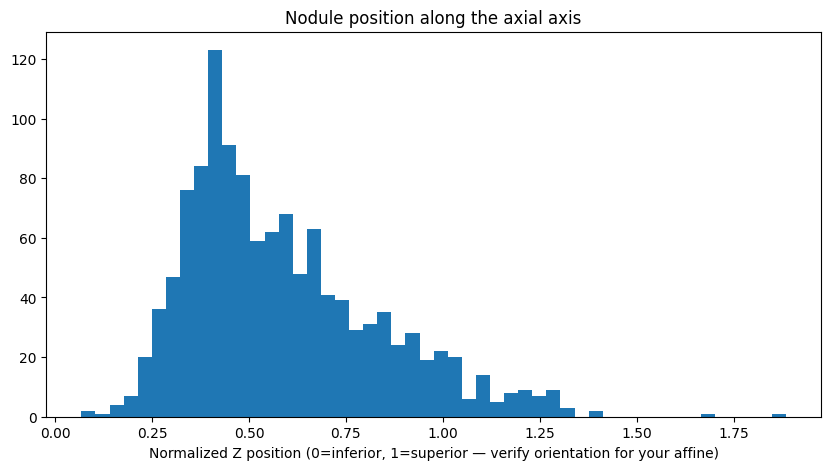

In [7]:
plt.figure(figsize=(10, 5))
plt.hist(nodules_df["centroid_z_frac"], bins=50)
plt.xlabel("Normalized Z position (0=inferior, 1=superior — verify orientation for your affine)")
plt.title("Nodule position along the axial axis")
plt.show()

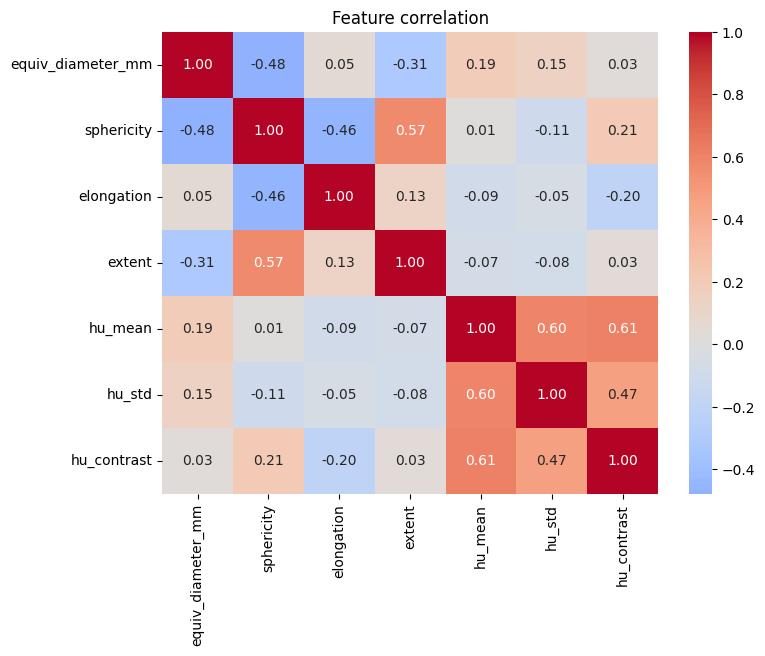

In [8]:
import seaborn as sns

feat_cols = ["equiv_diameter_mm", "sphericity", "elongation", "extent",
             "hu_mean", "hu_std", "hu_contrast"]
corr = nodules_df[feat_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation")
plt.show()

In [ ]:
# ============================================================
# Narrowest HU ranges containing given percentages of GT values
# ============================================================

def narrowest_hu_range(values, percentages=[1, 5, 10, 15, 50]):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    values = np.sort(values)

    n = values.size

    if n == 0:
        print("No HU values found.")
        return {}

    results = {}

    for p in percentages:
        # Number of voxels needed to include p%
        window_size = max(1, int(np.ceil((p / 100) * n)))

        # Sliding window over sorted HU values
        starts = values[: n - window_size + 1]
        ends = values[window_size - 1 :]

        widths = ends - starts
        best_idx = int(np.argmin(widths))

        hu_min = float(starts[best_idx])
        hu_max = float(ends[best_idx])
        width = float(hu_max - hu_min)

        results[p] = {
            "min": hu_min,
            "max": hu_max,
            "width": width,
            "voxels": window_size,
        }

        print(f"{p}% HU range:")
        print(f"  Min HU : {hu_min:.2f}")
        print(f"  Max HU : {hu_max:.2f}")
        print(f"  Width  : {width:.2f}")
        print(f"  Voxels : {window_size}")
        print()

    return results


hu_ranges = narrowest_hu_range(gt_hu_values, percentages=[1, 5, 10, 25, 50])

1% HU range:
  Min HU : -832.00
  Max HU : -832.00
  Width  : 0.00
  Voxels : 5

5% HU range:
  Min HU : -823.00
  Max HU : -816.00
  Width  : 7.00
  Voxels : 22

10% HU range:
  Min HU : -832.00
  Max HU : -815.00
  Width  : 17.00
  Voxels : 44

25% HU range:
  Min HU : -841.00
  Max HU : -784.00
  Width  : 57.00
  Voxels : 109

50% HU range:
  Min HU : -845.00
  Max HU : -681.00
  Width  : 164.00
  Voxels : 218



In [6]:
hu_ranges_all = narrowest_hu_range(
    all_hu_values,
    percentages=[1, 5, 10, 25, 50]
)

1% HU range:
  Min HU : -1.00
  Max HU : 0.00
  Width  : 1.00
  Voxels : 20081

5% HU range:
  Min HU : 23.00
  Max HU : 28.00
  Width  : 5.00
  Voxels : 100401

10% HU range:
  Min HU : 21.00
  Max HU : 32.00
  Width  : 11.00
  Voxels : 200801

25% HU range:
  Min HU : 13.00
  Max HU : 43.00
  Width  : 30.00
  Voxels : 502002

50% HU range:
  Min HU : -12.00
  Max HU : 64.00
  Width  : 76.00
  Voxels : 1004004



In [ ]:
import os
import json
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths
# --------------------------------------------------

volume_dir = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed"
mask_dir = "/home/chest_ct/code/data/segmentations/segmentations"

json_path = "/home/chest_ct/code/data/rexgrounding-ct/dataset_2d.json"

# --------------------------------------------------
# Load selected cases
# --------------------------------------------------

with open(json_path, "r") as f:
    dataset = json.load(f)

selected_files = set(
    dataset.get("train", []) +
    dataset.get("test", [])
)

print(f"Selected CTs: {len(selected_files)}")

# --------------------------------------------------
# Collect HU values
# --------------------------------------------------

all_hu_values = []

processed = 0
missing_ct = []
missing_mask = []

for filename in sorted(selected_files):

    volume_path = os.path.join(volume_dir, filename)
    mask_path = os.path.join(mask_dir, filename)

    if not os.path.exists(volume_path):
        missing_ct.append(filename)
        continue

    if not os.path.exists(mask_path):
        missing_mask.append(filename)
        continue

    try:
        ct = nib.load(volume_path).get_fdata()
        gt_mask = nib.load(mask_path).get_fdata()

        # Multi-channel mask -> union of channels
        if gt_mask.ndim == 4:
            gt_mask = np.any(gt_mask > 0, axis=0)
        else:
            gt_mask = gt_mask > 0

        hu_values = ct[gt_mask]
        hu_values = hu_values[np.isfinite(hu_values)]

        if hu_values.size > 0:
            all_hu_values.append(hu_values)

        processed += 1

    except Exception as e:
        print(f"Error processing {filename}: {e}")

# --------------------------------------------------
# Summary
# --------------------------------------------------

print(f"\nProcessed: {processed}")
print(f"Missing CTs: {len(missing_ct)}")
print(f"Missing masks: {len(missing_mask)}")

if missing_ct:
    print("\nMissing CT files:")
    for x in missing_ct[:20]:
        print(" ", x)

if missing_mask:
    print("\nMissing mask files:")
    for x in missing_mask[:20]:
        print(" ", x)

# --------------------------------------------------
# HU statistics
# --------------------------------------------------

all_hu_values = np.concatenate(all_hu_values)

print("\n========== GLOBAL NODULE HU STATS ==========")
print("Voxel count:", all_hu_values.size)

for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"P{p:<2}:", float(np.percentile(all_hu_values, p)))

print("Min   :", float(np.min(all_hu_values)))
print("Max   :", float(np.max(all_hu_values)))
print("Mean  :", float(np.mean(all_hu_values)))
print("Median:", float(np.median(all_hu_values)))
print("Std   :", float(np.std(all_hu_values)))

# --------------------------------------------------
# Histogram
# --------------------------------------------------

plt.figure(figsize=(12, 6))
plt.hist(all_hu_values, bins=200)
plt.xlabel("HU Value")
plt.ylabel("Voxel Count")
plt.title("HU Distribution of Nodule Voxels")
plt.grid(alpha=0.3)
plt.show()

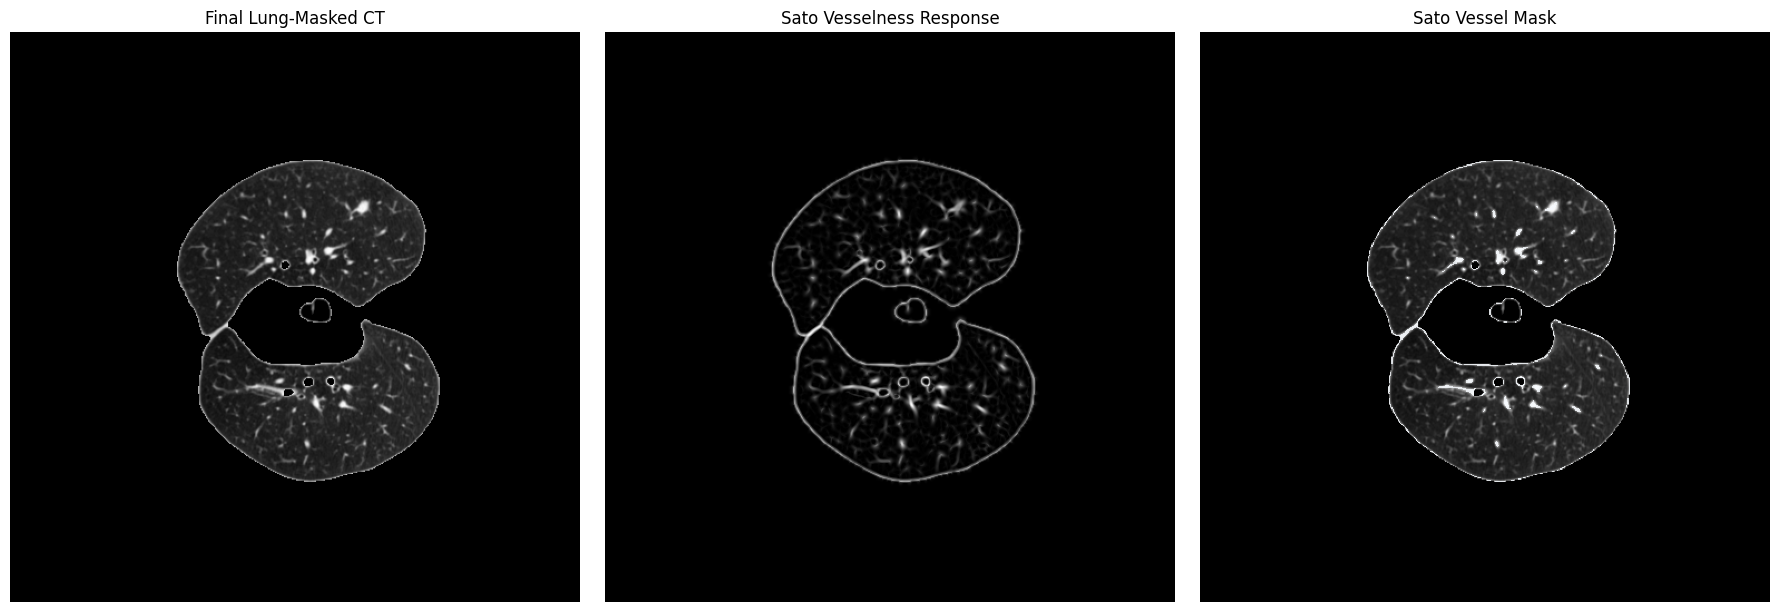

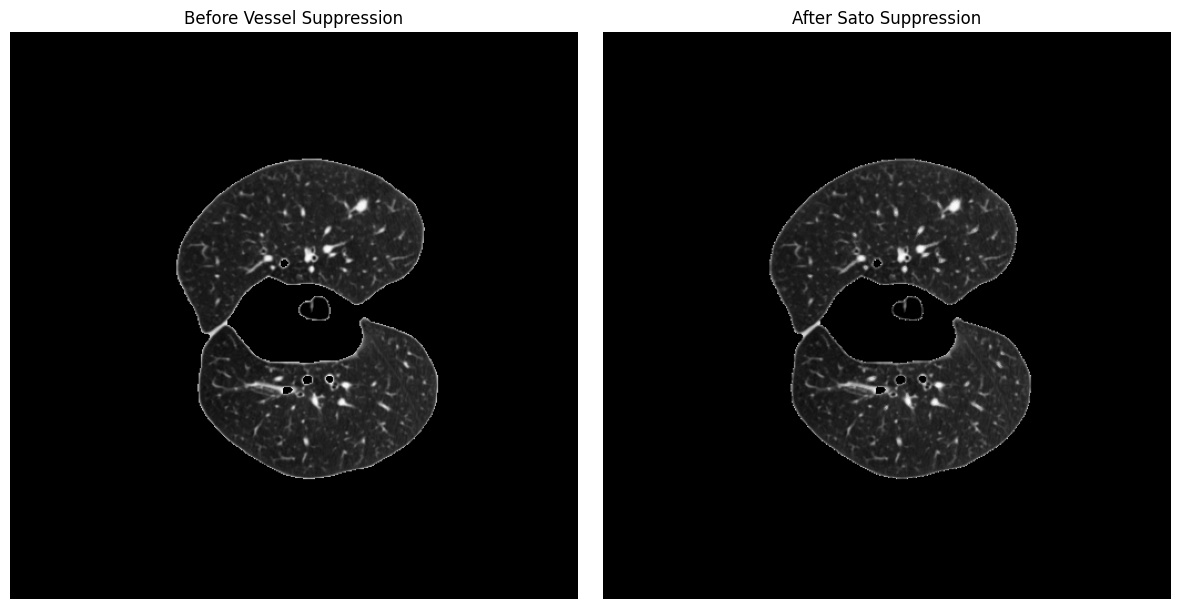

Slice index: 333

Sato vessel candidate pixel count on this slice:
Sato vessel pixels: 1316


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage
from skimage.filters import sato


# ============================================================
# Helper: normalize one CT slice inside lung
# ============================================================
def normalize_lung_slice(ct_slice, lung_slice, hu_min=-900, hu_max=200):
    """
    Clip one CT slice and normalize to [0, 1].
    Outside lung is set to 0.
    """
    ct_clip = np.clip(ct_slice, hu_min, hu_max)
    ct_norm = (ct_clip - hu_min) / (hu_max - hu_min)
    ct_norm[~lung_slice] = 0
    return ct_norm


# ============================================================
# Helper: suppress vessels on one slice only
# ============================================================
def suppress_vessels_from_slice(
    ct_slice,
    vesselness_slice,
    lung_slice,
    percentile=3
):
    """
    Suppress likely vessel pixels on one 2D slice.
    Vessel pixels are replaced by local median values.
    """
    values = vesselness_slice[lung_slice]

    if values.size == 0:
        return ct_slice.copy(), np.zeros_like(lung_slice, dtype=bool)

    threshold = np.percentile(values, percentile)

    vessel_mask = (vesselness_slice >= threshold) & lung_slice

    local_median = ndimage.median_filter(ct_slice, size=3)

    ct_suppressed = ct_slice.copy()
    ct_suppressed[vessel_mask] = local_median[vessel_mask]

    return ct_suppressed, vessel_mask


# ============================================================
# 1. Extract selected slice
# ============================================================
ct_slice = ct_lung_only[:, :, slice_idx]
lung_slice = lungs_final[:, :, slice_idx]


# ============================================================
# 2. Normalize selected slice for vessel filter
# ============================================================
ct_norm_slice = normalize_lung_slice(
    ct_slice=ct_slice,
    lung_slice=lung_slice,
    hu_min=-900,
    hu_max=200
)


# ============================================================
# 3. Apply Sato vessel filter on 2D slice
# ============================================================
sato_slice = sato(
    ct_norm_slice,
    sigmas=(1, 2),
    black_ridges=False
)


# ============================================================
# 4. Suppress vessel pixels using Sato response
# ============================================================
sato_removed_slice, sato_mask_slice = suppress_vessels_from_slice(
    ct_slice=ct_slice,
    vesselness_slice=sato_slice,
    lung_slice=lung_slice,
    percentile=97
)


# ============================================================
# 5. Visualize CT, Sato response, and vessel mask
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(ct_slice, cmap="gray")
axes[0].set_title("Final Lung-Masked CT")
axes[0].axis("off")

axes[1].imshow(sato_slice, cmap="gray")
axes[1].set_title("Sato Vesselness Response")
axes[1].axis("off")

axes[2].imshow(ct_slice, cmap="gray")
axes[2].imshow(
    np.ma.masked_where(~sato_mask_slice, sato_mask_slice),
    cmap="Blues",
    alpha=0.8,
    interpolation="none"
)
axes[2].set_title("Sato Vessel Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 6. Visualize before/after vessel suppression
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(ct_slice, cmap="gray")
axes[0].set_title("Before Vessel Suppression")
axes[0].axis("off")

axes[1].imshow(sato_removed_slice, cmap="gray")
axes[1].set_title("After Sato Suppression")
axes[1].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 7. Print statistics for this slice
# ============================================================
print("Slice index:", slice_idx)
print("\nSato vessel candidate pixel count on this slice:")
print("Sato vessel pixels:", int(sato_mask_slice.sum()))

In [11]:
# ============================================================
# Whole-volume nodule pipeline after lung segmentation
# Windowing -> slice-wise Sato -> vessel removal -> components -> evaluation
# ============================================================

from skimage.filters import sato
from skimage.measure import label, regionprops
import numpy as np

LOW_HU = -150
HIGH_HU = 200
SATO_PERCENTILE = 98.5
MIN_VOXELS = 20
MAX_VOXELS = 5000

# 1. HU windowing inside segmented lungs
nodule_candidate_3d = lungs_final & (
    (ct_lung_only >= LOW_HU) & (ct_lung_only <= HIGH_HU)
)

# 2. Sato vessel detection slice-by-slice
vessel_mask_3d = np.zeros_like(lungs_final, dtype=bool)

for k in range(ct_lung_only.shape[2]):
    lung_slice = lungs_final[:, :, k]

    if lung_slice.sum() == 0:
        continue

    ct_slice = ct_lung_only[:, :, k]

    ct_norm = np.clip(ct_slice, -900, 200)
    ct_norm = (ct_norm + 900) / 1100
    ct_norm[~lung_slice] = 0

    vesselness = sato(ct_norm, sigmas=(1, 2), black_ridges=False)

    vessel_mask_3d[:, :, k] = (
        vesselness >= np.percentile(vesselness[lung_slice], SATO_PERCENTILE)
    ) & lung_slice

# 3. Remove vessel-like pixels
candidate_no_vessels_3d = nodule_candidate_3d & ~vessel_mask_3d

# 4. Connected component filtering
labeled = label(candidate_no_vessels_3d, connectivity=1)
final_candidate_3d = np.zeros_like(candidate_no_vessels_3d, dtype=bool)

for region in regionprops(labeled):
    if MIN_VOXELS <= region.area <= MAX_VOXELS:
        final_candidate_3d[labeled == region.label] = True

# 5. Evaluation against GT
gt_3d = gt_mask > 0
pred_3d = final_candidate_3d > 0

tp = np.logical_and(pred_3d, gt_3d).sum()
fp = np.logical_and(pred_3d, ~gt_3d).sum()
fn = np.logical_and(~pred_3d, gt_3d).sum()
tn = np.logical_and(~pred_3d, ~gt_3d).sum()

dice = (2 * tp) / (2 * tp + fp + fn + 1e-8)
iou = tp / (tp + fp + fn + 1e-8)
precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)

print("Dice       :", float(dice))
print("IoU        :", float(iou))
print("Precision  :", float(precision))
print("Recall     :", float(recall))
print("Specificity:", float(specificity))

print("\nTP:", int(tp))
print("FP:", int(fp))
print("FN:", int(fn))
print("TN:", int(tn))

Dice       : 0.1187983419511479
IoU        : 0.06315024306025935
Precision  : 0.0860787713648216
Recall     : 0.1916448366190657
Specificity: 0.999877872708755

TP: 1390
FP: 14758
FN: 5863
TN: 120826373


Dice       : 0.0
IoU        : 0.0
Precision  : 0.0
Recall     : 0.0
Specificity: 0.9998796311321002
TP: 0 FP: 16976 FN: 327 TN: 141016169


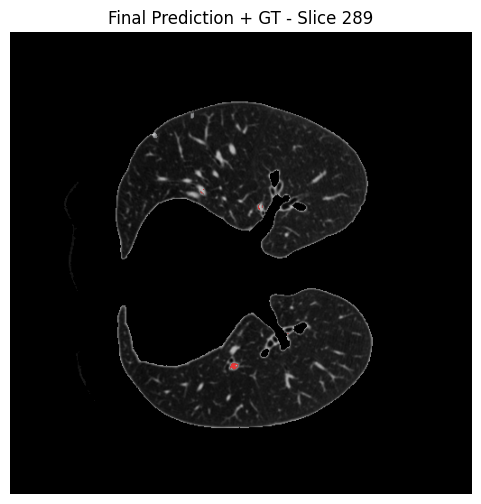

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.segmentation import clear_border
from skimage.measure import label, regionprops
from skimage.filters import sato

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Load NIfTI files
# -----------------------------

volume_path = r"/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_2381_a_2.nii.gz"

mask_path = r"/home/chest_ct/code/data/segmentations/segmentations/train_2381_a_2.nii.gz"

ct = nib.load(volume_path).get_fdata()
gt_mask = nib.load(mask_path).get_fdata()

if gt_mask.ndim == 4:
    gt_mask = gt_mask[0]
gt_mask = gt_mask > 0

# ct = ct - 1024  # uncomment only if CT is raw 0-4095, not HU

def keep_largest_components(binary_mask, n=2):
    labeled, num = label(binary_mask, return_num=True, connectivity=1)
    if num == 0:
        return np.zeros_like(binary_mask, dtype=bool)
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    return np.isin(labeled, np.argsort(sizes)[-n:])

slice_idx = int(np.argmax(gt_mask.sum(axis=(0, 1))))

lung_candidate = (ct >= -900) & (ct <= -200)

mask_clear = np.zeros_like(lung_candidate, dtype=bool)
for k in range(lung_candidate.shape[2]):
    mask_clear[:, :, k] = clear_border(lung_candidate[:, :, k])

lungs_final = keep_largest_components(mask_clear, n=2)

structure = ndimage.generate_binary_structure(3, 2)
lungs_final = ndimage.binary_closing(lungs_final, structure=structure, iterations=2)
lungs_final = ndimage.binary_fill_holes(lungs_final)
lungs_final = ndimage.binary_closing(lungs_final, structure=structure, iterations=2)
lungs_final = ndimage.binary_fill_holes(lungs_final)

ct_lung_only = ct.copy()
ct_lung_only[~lungs_final] = -1000

LOW_HU = -150
HIGH_HU = 200
SATO_PERCENTILE = 98.5
MIN_VOXELS = 35
MAX_VOXELS = 3365

nodule_candidate = lungs_final & ((ct_lung_only >= LOW_HU) & (ct_lung_only <= HIGH_HU))

vessel_mask = np.zeros_like(lungs_final, dtype=bool)

for k in range(ct_lung_only.shape[2]):
    lung_slice = lungs_final[:, :, k]
    if lung_slice.sum() == 0:
        continue

    ct_slice = ct_lung_only[:, :, k]
    ct_norm = np.clip(ct_slice, -900, 200)
    ct_norm = (ct_norm + 900) / 1100
    ct_norm[~lung_slice] = 0

    vesselness = sato(ct_norm, sigmas=(1, 2), black_ridges=False)
    vessel_mask[:, :, k] = (
        vesselness >= np.percentile(vesselness[lung_slice], SATO_PERCENTILE)
    ) & lung_slice

candidate_no_vessels = nodule_candidate & ~vessel_mask

labeled = label(candidate_no_vessels, connectivity=1)
final_candidate = np.zeros_like(candidate_no_vessels, dtype=bool)

for region in regionprops(labeled):
    if MIN_VOXELS <= region.area <= MAX_VOXELS:
        final_candidate[labeled == region.label] = True

pred = final_candidate > 0
gt = gt_mask > 0

tp = np.logical_and(pred, gt).sum()
fp = np.logical_and(pred, ~gt).sum()
fn = np.logical_and(~pred, gt).sum()
tn = np.logical_and(~pred, ~gt).sum()

dice = (2 * tp) / (2 * tp + fp + fn + 1e-8)
iou = tp / (tp + fp + fn + 1e-8)
precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)

print("Dice       :", float(dice))
print("IoU        :", float(iou))
print("Precision  :", float(precision))
print("Recall     :", float(recall))
print("Specificity:", float(specificity))
print("TP:", int(tp), "FP:", int(fp), "FN:", int(fn), "TN:", int(tn))

ct_slice = ct_lung_only[:, :, slice_idx]
gt_slice = gt_mask[:, :, slice_idx]
pred_slice = final_candidate[:, :, slice_idx]

plt.figure(figsize=(6, 6))
plt.imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
plt.imshow(np.ma.masked_where(~pred_slice, pred_slice), cmap="autumn", alpha=0.7)
plt.imshow(np.ma.masked_where(~gt_slice, gt_slice), cmap="Blues", alpha=0.4)
plt.title(f"Final Prediction + GT - Slice {slice_idx}")
plt.axis("off")
plt.show()

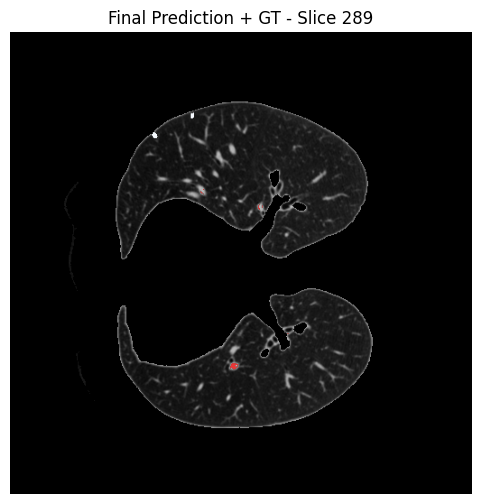

In [8]:
plt.figure(figsize=(6, 6))
plt.imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
plt.imshow(np.ma.masked_where(~pred_slice, pred_slice), cmap="autumn", alpha=0.7)
plt.imshow(np.ma.masked_where(~gt_slice, gt_slice), cmap="Blues", alpha=1)
plt.title(f"Final Prediction + GT - Slice {slice_idx}")
plt.axis("off")
plt.show()

In [ ]:
# ============================================================
# Save final nodule segmentation as NIfTI
# ============================================================

output_path = r"/home/chest_ct/code/image-processing/outputs/classical/train_2381_a_2.nii.gz"

ct_img = nib.load(volume_path)

seg_img = nib.Nifti1Image(
    final_candidate.astype(np.uint8),
    affine=ct_img.affine,
    header=ct_img.header
)

nib.save(seg_img, output_path)

print("Saved final nodule segmentation:")
print(output_path)
print("Positive voxels:", int(final_candidate.sum()))

Saved final nodule segmentation:
D:\My\Projects\fyp-3d-ct\outputs\final_nodule_segmentation.nii.gz
Positive voxels: 14499


In [4]:
import json
import nibabel as nib
import numpy as np
import pandas as pd
from pathlib import Path

json_path = Path("/home/chest_ct/code/data/rexgrounding-ct/dataset_2d.json")
mask_dir = Path("/home/chest_ct/code/data/segmentations/segmentations")

with open(json_path, "r") as f:
    dataset = json.load(f)

case_names = []
for split in ["train", "val", "test"]:
    case_names.extend(dataset.get(split, []))

rows = []

for name in sorted(set(case_names)):
    mask_path = mask_dir / name

    if not mask_path.exists():
        rows.append({
            "mask_name": name,
            "exists": False,
            "shape": None,
            "gt_voxel_count": 0,
        })
        continue

    mask_img = nib.load(str(mask_path))
    gt_mask = mask_img.get_fdata()

    if gt_mask.ndim == 4:
        gt_binary = np.any(gt_mask > 0, axis=0)
    else:
        gt_binary = gt_mask > 0

    rows.append({
        "mask_name": name,
        "exists": True,
        "shape": gt_mask.shape,
        "gt_voxel_count": int(gt_binary.sum()),
    })

df = pd.DataFrame(rows)

print("Cases in JSON:", len(case_names))
print("Unique cases :", len(set(case_names)))
print("Masks found  :", int(df["exists"].sum()))
print("Masks missing:", int((~df["exists"]).sum()))
print("Total GT voxels:", int(df["gt_voxel_count"].sum()))

print("\nSummary")
print(df[df["exists"]]["gt_voxel_count"].describe())

print("\nTop 10 largest GT masks")
display(df[df["exists"]].sort_values("gt_voxel_count", ascending=False).head(10))

print("\nTop 10 smallest GT masks")
display(df[df["exists"]].sort_values("gt_voxel_count", ascending=True).head(10))

print("\nMissing masks")
display(df[~df["exists"]])

Cases in JSON: 524
Unique cases : 524
Masks found  : 524
Masks missing: 0
Total GT voxels: 2191527

Summary
count    5.240000e+02
mean     4.182303e+03
std      4.759538e+04
min      1.000000e+01
25%      1.890000e+02
50%      3.550000e+02
75%      9.362500e+02
max      1.021342e+06
Name: gt_voxel_count, dtype: float64

Top 10 largest GT masks


,mask_name,exists,shape,gt_voxel_count
248,train_340_a_1.nii.gz,True,"(5, 768, 768, 215)",1021342
78,train_1157_e_2.nii.gz,True,"(6, 512, 512, 428)",288803
98,train_119_a_2.nii.gz,True,"(4, 512, 512, 487)",187049
400,train_7641_b_2.nii.gz,True,"(2, 512, 512, 229)",148015
499,valid_660_a_2.nii.gz,True,"(1, 512, 512, 465)",91010
176,train_1758_a_2.nii.gz,True,"(3, 512, 512, 179)",29390
58,train_11023_b_1.nii.gz,True,"(3, 768, 768, 217)",12326
460,valid_1103_a_2.nii.gz,True,"(1, 512, 512, 422)",11933
478,valid_382_c_2.nii.gz,True,"(2, 512, 512, 234)",10729
214,train_2323_a_2.nii.gz,True,"(1, 512, 512, 420)",10683



Top 10 smallest GT masks


,mask_name,exists,shape,gt_voxel_count
251,train_3580_a_2.nii.gz,True,"(1, 512, 512, 298)",10
177,train_176_a_2.nii.gz,True,"(1, 512, 512, 559)",21
293,train_5627_a_1.nii.gz,True,"(1, 512, 512, 320)",27
441,train_8095_a_2.nii.gz,True,"(1, 512, 512, 254)",31
320,train_6156_a_2.nii.gz,True,"(1, 512, 512, 440)",32
321,train_6161_a_1.nii.gz,True,"(1, 512, 512, 374)",35
85,train_11749_a_1.nii.gz,True,"(1, 512, 512, 216)",36
210,train_229_a_1.nii.gz,True,"(1, 512, 512, 330)",41
442,train_8163_a_1.nii.gz,True,"(1, 768, 768, 195)",45
7,train_10106_a_2.nii.gz,True,"(1, 512, 512, 450)",50



Missing masks


,mask_name,exists,shape,gt_voxel_count


In [5]:
valid_sizes = df[df["exists"]]["gt_voxel_count"]

print("GT voxel count percentiles")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"P{p:<2}:", int(valid_sizes.quantile(p / 100)))

print("\nRecommended component ranges")
print("Strict small nodules :", int(valid_sizes.quantile(0.05)), "to", int(valid_sizes.quantile(0.95)))
print("Broad nodules        :", int(valid_sizes.quantile(0.01)), "to", int(valid_sizes.quantile(0.99)))

GT voxel count percentiles
P1 : 35
P5 : 71
P10: 107
P25: 189
P50: 355
P75: 936
P90: 2068
P95: 3364
P99: 25465

Recommended component ranges
Strict small nodules : 71 to 3364
Broad nodules        : 35 to 25465


In [13]:
import json
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
from scipy import ndimage
from skimage.filters import sato
from skimage.measure import label, regionprops
from skimage.segmentation import clear_border

dataset_json = Path("/home/chest_ct/code/data/rexgrounding-ct/dataset_2d.json")
volume_root = Path("/home/chest_ct/code/data/data_volumes/dataset/train_fixed")
mask_root = Path("/home/chest_ct/code/data/segmentations/segmentations")

out_dir = Path("/home/chest_ct/code/image-processing/outputs/classical")
out_seg_dir = out_dir / "segmentations"
out_csv = out_dir / "nodule_image_pipeline_results_dataset2d.csv"

out_dir.mkdir(parents=True, exist_ok=True)
out_seg_dir.mkdir(parents=True, exist_ok=True)

MIN_VOXELS = 35
MAX_VOXELS = 3365
APPLY_CT_OFFSET = False


def keep_largest_components(binary_mask, n=2):
    labeled, num = label(binary_mask, return_num=True, connectivity=1)
    if num == 0:
        return np.zeros_like(binary_mask, dtype=bool)

    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    largest_labels = np.argsort(sizes)[-n:]

    return np.isin(labeled, largest_labels)


def resolve_volume_path(filename):
    direct_path = volume_root / filename
    if direct_path.exists():
        return direct_path

    matches = list(volume_root.rglob(filename))
    return matches[0] if matches else None


def resolve_mask_path(filename):
    mask_path = mask_root / filename
    return mask_path if mask_path.exists() else None


def run_case(volume_path, mask_path, filename):
    ct_img = nib.load(str(volume_path))
    ct = ct_img.get_fdata().astype(np.float32)

    gt_mask = nib.load(str(mask_path)).get_fdata()
    if gt_mask.ndim == 4:
        gt_mask = gt_mask[0]
    gt_mask = gt_mask > 0


    # Lung segmentation
    lung_candidate = (ct >= -900) & (ct <= -200)

    mask_clear = np.zeros_like(lung_candidate, dtype=bool)
    for k in range(lung_candidate.shape[2]):
        mask_clear[:, :, k] = clear_border(lung_candidate[:, :, k])

    lungs_only = keep_largest_components(mask_clear, n=2)

    structure_3d = ndimage.generate_binary_structure(3, 2)
    lungs_final = ndimage.binary_closing(lungs_only, structure=structure_3d, iterations=2)
    lungs_final = ndimage.binary_fill_holes(lungs_final)
    lungs_final = ndimage.binary_closing(lungs_final, structure=structure_3d, iterations=2)
    lungs_final = ndimage.binary_fill_holes(lungs_final)

    ct_lung_only = ct.copy()
    ct_lung_only[~lungs_final] = -1000

    # Nodule HU windowing
    nodule_candidate = lungs_final & (
        (ct_lung_only >= -100) & (ct_lung_only <= 150)
    )

    # Sato vessel removal
    vessel_mask = np.zeros_like(lungs_final, dtype=bool)

    for k in range(ct_lung_only.shape[2]):
        lung_slice = lungs_final[:, :, k]

        if lung_slice.sum() == 0:
            continue

        ct_slice = ct_lung_only[:, :, k]

        ct_norm = np.clip(ct_slice, -900, 200)
        ct_norm = (ct_norm + 900) / 1100.0
        ct_norm[~lung_slice] = 0

        vesselness = sato(ct_norm, sigmas=(1, 2), black_ridges=False)

        vessel_mask[:, :, k] = (
            vesselness >= np.percentile(vesselness[lung_slice], 98.5)
        ) & lung_slice

    candidate_after_sato = nodule_candidate & ~vessel_mask

    # 3D morphology + component filtering
    structure_3d_small = ndimage.generate_binary_structure(3, 1)

    candidate_closed = ndimage.binary_closing(
        candidate_after_sato,
        structure=structure_3d_small,
        iterations=1,
    )

    candidate_filled = ndimage.binary_fill_holes(candidate_closed)

    candidate_clean = ndimage.binary_opening(
        candidate_filled,
        structure=structure_3d_small,
        iterations=1,
    )

    labels_3d = label(candidate_clean, connectivity=1)
    final_candidate = np.zeros_like(candidate_clean, dtype=bool)

    valid_regions = [
        region for region in regionprops(labels_3d)
        if MIN_VOXELS <= region.area <= MAX_VOXELS
    ]

    valid_regions = sorted(valid_regions, key=lambda r: r.area, reverse=True)[:2]

    kept_components = 0

    for region in valid_regions:
        final_candidate[labels_3d == region.label] = True
        kept_components += 1

    # Save final segmentation
    seg_path = out_seg_dir / filename

    seg_img = nib.Nifti1Image(
        final_candidate.astype(np.uint8),
        affine=ct_img.affine,
        header=ct_img.header,
    )

    nib.save(seg_img, str(seg_path))

    # Metrics
    pred = final_candidate
    gt = gt_mask

    tp = int(np.logical_and(pred, gt).sum())
    fp = int(np.logical_and(pred, ~gt).sum())
    fn = int(np.logical_and(~pred, gt).sum())
    tn = int(np.logical_and(~pred, ~gt).sum())

    dice = (2 * tp) / (2 * tp + fp + fn + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)

    return {
        "shape": tuple(ct.shape),
        "gt_voxels": int(gt.sum()),
        "lung_voxels": int(lungs_final.sum()),
        "hu_candidate_voxels": int(nodule_candidate.sum()),
        "after_sato_voxels": int(candidate_after_sato.sum()),
        "final_candidate_voxels": int(final_candidate.sum()),
        "kept_components": kept_components,
        "segmentation_path": str(seg_path),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
    }


with open(dataset_json, "r") as f:
    dataset = json.load(f)

all_names = [("train", n) for n in dataset["train"]] + [("test", n) for n in dataset["test"]]

if out_csv.exists():
    results_df = pd.read_csv(out_csv)
    done_names = set(results_df["name"].tolist())
    rows = results_df.to_dict("records")
    print(f"Resuming from existing CSV: {len(done_names)} cases already saved")
else:
    rows = []
    done_names = set()

total_cases = len(all_names)

for i, (split_name, filename) in enumerate(all_names, 1):
    if filename in done_names:
        print(f"[{i}/{total_cases}] skip: {filename} already processed")
        continue

    volume_path = resolve_volume_path(filename)
    mask_path = resolve_mask_path(filename)

    if volume_path is None or mask_path is None:
        row = {
            "split": split_name,
            "name": filename,
            "status": "missing_file",
            "volume_path": str(volume_path) if volume_path else None,
            "mask_path": str(mask_path) if mask_path else None,
        }

        rows.append(row)
        pd.DataFrame(rows).to_csv(out_csv, index=False)

        print(f"[{i}/{total_cases}] missing: {filename}")
        continue

    try:
        result = run_case(volume_path, mask_path, filename)

        row = {
            "split": split_name,
            "name": filename,
            "status": "ok",
            "volume_path": str(volume_path),
            "mask_path": str(mask_path),
            **result,
        }

        rows.append(row)
        pd.DataFrame(rows).to_csv(out_csv, index=False)

        print(f"[{i}/{total_cases}] done: {filename}")
        print(
            f"  Dice={result['dice']:.4f}  "
            f"IoU={result['iou']:.4f}  "
            f"Precision={result['precision']:.4f}  "
            f"Recall={result['recall']:.4f}"
        )
        print(
            f"  GT={result['gt_voxels']}  "
            f"FinalPred={result['final_candidate_voxels']}  "
            f"Components={result['kept_components']}"
        )
        print(f"  Saved segmentation: {result['segmentation_path']}")

    except Exception as e:
        row = {
            "split": split_name,
            "name": filename,
            "status": f"error: {type(e).__name__}",
            "volume_path": str(volume_path),
            "mask_path": str(mask_path),
            "error_message": str(e),
        }

        rows.append(row)
        pd.DataFrame(rows).to_csv(out_csv, index=False)

        print(f"[{i}/{total_cases}] error: {filename}")
        print(f"  {type(e).__name__}: {e}")


df = pd.DataFrame(rows)
ok_df = df[df["status"] == "ok"].copy()

print("\nSaved results to:", out_csv)
print("Saved segmentations to:", out_seg_dir)
print("Completed cases:", len(ok_df), "/", len(df))

if len(ok_df) > 0:
    print("\nMean metrics")
    print(ok_df[["dice", "iou", "precision", "recall", "specificity"]].mean())

    print("\nMedian metrics")
    print(ok_df[["dice", "iou", "precision", "recall", "specificity"]].median())

[1/524] done: train_1696_a_2.nii.gz
  Dice=0.0000  IoU=0.0000  Precision=0.0000  Recall=0.0000
  GT=436  FinalPred=448  Components=2
  Saved segmentation: /home/chest_ct/code/image-processing/outputs/classical/segmentations/train_1696_a_2.nii.gz
[2/524] done: train_2381_a_2.nii.gz
  Dice=0.0000  IoU=0.0000  Precision=0.0000  Recall=0.0000
  GT=327  FinalPred=1448  Components=2
  Saved segmentation: /home/chest_ct/code/image-processing/outputs/classical/segmentations/train_2381_a_2.nii.gz
[3/524] done: train_1606_a_2.nii.gz
  Dice=0.0000  IoU=0.0000  Precision=0.0000  Recall=0.0000
  GT=261  FinalPred=1076  Components=2
  Saved segmentation: /home/chest_ct/code/image-processing/outputs/classical/segmentations/train_1606_a_2.nii.gz
[4/524] done: train_1860_a_1.nii.gz
  Dice=0.0000  IoU=0.0000  Precision=0.0000  Recall=0.0000
  GT=668  FinalPred=4495  Components=2
  Saved segmentation: /home/chest_ct/code/image-processing/outputs/classical/segmentations/train_1860_a_1.nii.gz
[5/524] done: